# Full Test: CPU vs OpenACC (GPU) Comparison

Comparing IQ-TREE ModelFinder + tree reconstruction results across 4 workflows:
- **VANILA** (1 CPU thread)
- **OMP_10** (10 CPU threads)
- **OMP_48** (48 CPU threads)
- **OPENACC** (GPU V100)

**Datasets**: 100 taxa, GTR+I+G4 (DNA) and LG+I+G4 (AA), alignment lengths 100 to 1M sites

**Analysis**: Model selection agreement, log-likelihood accuracy, wall-clock time, speedup

In [6]:
import os
import re
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.colors as mcolors
import numpy as np

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

RESULTS_BASE = '/Users/u7826985/Projects/Nvidia/results/2026_03_30_full_test'
SAVE_DIR = '/Users/u7826985/Projects/Nvidia/poc-gpu-likelihood-calculation_analysis/2026_03_30_full_test'

# Shared plot styles
colors = {'1 CPU': '#1f77b4', '10 CPUs': '#ff7f0e', '48 CPUs': '#2ca02c', 'GPU (V100)': '#d62728'}
markers = {'1 CPU': 'o', '10 CPUs': 's', '48 CPUs': '^', 'GPU (V100)': 'D'}
wf_labels = {'VANILA': '1 CPU', 'OMP_10': '10 CPUs', 'OMP_48': '48 CPUs', 'OPENACC': 'GPU (V100)'}
wf_order = ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']

def fmt_time(sec):
    if pd.isna(sec): return 'N/A'
    if sec < 60: return f'{sec:.1f}s'
    if sec < 3600: return f'{sec/60:.1f}m'
    return f'{sec/3600:.1f}h'

## 1. Data Loading and Parsing

In [7]:
def parse_iqtree_file(filepath):
    """Parse .iqtree file for key metrics."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()
    
    m = re.search(r'Best-fit model according to BIC:\s+(\S+)', content)
    if m: data['best_model'] = m.group(1)
    
    m = re.search(r'Log-likelihood of the tree:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))
    
    m = re.search(r'Bayesian information criterion \(BIC\) score:\s+([\d.]+)', content)
    if m: data['bic'] = float(m.group(1))
    
    m = re.search(r'Akaike information criterion \(AIC\) score:\s+([\d.]+)', content)
    if m: data['aic'] = float(m.group(1))
    
    m = re.search(r'Number of free parameters.*?:\s+(\d+)', content)
    if m: data['free_params'] = int(m.group(1))
    
    m = re.search(r'Gamma shape alpha:\s+([\d.]+)', content)
    if m: data['gamma_alpha'] = float(m.group(1))
    
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))
    
    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))
    
    return data

def parse_log_file(filepath):
    """Parse .log file as fallback."""
    data = {}
    with open(filepath, 'r') as f:
        content = f.read()
    
    m = re.search(r'Best-fit model:\s+(\S+)\s+chosen', content)
    if m: data['best_model'] = m.group(1)
    
    m = re.search(r'Optimal log-likelihood:\s+([\-\d.]+)', content)
    if m: data['log_likelihood'] = float(m.group(1))
    
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)', content)
    if m: data['wall_time_sec'] = float(m.group(1))
    
    m = re.search(r'Total CPU time used:\s+([\d.]+)', content)
    if m: data['cpu_time_sec'] = float(m.group(1))
    
    return data

def parse_model_table(filepath):
    """Parse the 'List of models sorted by BIC scores' table from .iqtree file."""
    models = []
    with open(filepath, 'r') as f:
        content = f.read()
    
    table_match = re.search(r'Model\s+LogL\s+AIC.*?BIC.*?\n(.*?)(?:\n\n|\nAkaike|\nBayesian)', content, re.DOTALL)
    if not table_match:
        return models
    
    for line in table_match.group(1).strip().split('\n'):
        line = line.strip()
        if not line or line.startswith('---'):
            continue
        parts = line.split()
        if len(parts) >= 9:
            try:
                model_name = parts[0]
                lnl = float(parts[1])
                aic = float(parts[2])
                bic = float(parts[-3])
                models.append({'model': model_name, 'lnL': lnl, 'AIC': aic, 'BIC': bic})
            except (ValueError, IndexError):
                continue
    return models

def load_results(data_type):
    """Load results for a given data type (DNA or AA)."""
    results_dir = os.path.join(RESULTS_BASE, data_type)
    records = []
    lengths = [100, 1000, 10000, 100000, 1000000, 10000000]
    workflows = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
    
    for length in lengths:
        len_dir = os.path.join(results_dir, f'len_{length}')
        if not os.path.isdir(len_dir):
            continue
        for wf in workflows:
            iqtree_files = glob.glob(os.path.join(len_dir, f'*_{wf}_*.iqtree'))
            if iqtree_files:
                data = parse_iqtree_file(iqtree_files[0])
            else:
                log_files = glob.glob(os.path.join(len_dir, f'*_{wf}_*.log'))
                if log_files:
                    data = parse_log_file(log_files[0])
                else:
                    continue
            
            if not data or 'wall_time_sec' not in data:
                continue
            
            data['length'] = length
            data['workflow'] = wf
            data['data_type'] = data_type
            records.append(data)
    
    df = pd.DataFrame(records)
    if len(df) > 0:
        df['workflow_label'] = df['workflow'].map(wf_labels)
    return df

def load_model_details(data_type, lengths_to_use):
    """Load per-model results for detailed comparison."""
    results_dir = os.path.join(RESULTS_BASE, data_type)
    all_model_records = []
    workflows = ['VANILA', 'OMP_10', 'OMP_48', 'OPENACC']
    
    for length in lengths_to_use:
        len_dir = os.path.join(results_dir, f'len_{length}')
        if not os.path.isdir(len_dir):
            continue
        for wf in workflows:
            iqtree_files = glob.glob(os.path.join(len_dir, f'*_{wf}_*.iqtree'))
            if not iqtree_files:
                continue
            models = parse_model_table(iqtree_files[0])
            for m in models:
                m['length'] = length
                m['workflow'] = wf
                m['workflow_label'] = wf_labels[wf]
                all_model_records.append(m)
    
    return pd.DataFrame(all_model_records)

# Load all results
df_dna = load_results('DNA')
df_aa = load_results('AA')

print('=== DNA ===')
print(f"Parsed {len(df_dna)} results across {df_dna['length'].nunique()} alignment lengths")
print(f"Lengths: {sorted(df_dna['length'].unique())}")
print(f"Workflows: {sorted(df_dna['workflow_label'].unique())}")
print()
print('=== AA ===')
print(f"Parsed {len(df_aa)} results across {df_aa['length'].nunique()} alignment lengths")
print(f"Lengths: {sorted(df_aa['length'].unique())}")
print(f"Workflows: {sorted(df_aa['workflow_label'].unique())}")

=== DNA ===
Parsed 19 results across 5 alignment lengths
Lengths: [100, 1000, 10000, 100000, 1000000]
Workflows: ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']

=== AA ===
Parsed 15 results across 4 alignment lengths
Lengths: [100, 1000, 10000, 100000]
Workflows: ['1 CPU', '10 CPUs', '48 CPUs', 'GPU (V100)']


In [8]:
# Display full summary tables
display_cols = ['length', 'workflow_label', 'best_model', 'log_likelihood', 'wall_time_sec', 'cpu_time_sec']

print('=== DNA Results ===')
display(df_dna[[c for c in display_cols if c in df_dna.columns]].sort_values(['length', 'workflow_label']))

print('\n=== AA Results ===')
display(df_aa[[c for c in display_cols if c in df_aa.columns]].sort_values(['length', 'workflow_label']))

=== DNA Results ===


,length,workflow_label,best_model,log_likelihood,wall_time_sec,cpu_time_sec
0,100,1 CPU,F81+F+ASC+G4,-4.907728e+03,6.33987,5.84467
1,100,10 CPUs,F81+F+ASC+G4,-4.907728e+03,5.11802,50.20760
2,100,48 CPUs,F81+F+ASC+G4,-4.907728e+03,141.27200,2728.95000
3,100,GPU (V100),F81+F+ASC+G4,-4.907728e+03,58.32860,58.31100
4,1000,1 CPU,F81+F+G4,-5.618215e+04,24.09850,23.96090
5,1000,10 CPUs,F81+F+G4,-5.618215e+04,8.72638,85.77240
6,1000,48 CPUs,F81+F+G4,-5.618215e+04,19.25150,911.81800
7,1000,GPU (V100),F81+F+G4,-5.618215e+04,33.68940,33.67180
8,10000,1 CPU,F81+F+G4,-5.642088e+05,450.97200,446.86700
9,10000,10 CPUs,F81+F+G4,-5.642088e+05,67.27520,662.92300



=== AA Results ===


,length,workflow_label,best_model,log_likelihood,wall_time_sec,cpu_time_sec
0,100,1 CPU,LG+G4,-7.676571e+03,51.6069,48.4989
1,100,10 CPUs,LG+G4,-7.676571e+03,17.2095,168.3860
2,100,48 CPUs,LG+G4,-7.676571e+03,15.9998,195.5390
3,100,GPU (V100),LG+G4,-7.676571e+03,95.5669,95.4595
4,1000,1 CPU,LG+G4,-7.782396e+04,552.8090,549.4870
5,1000,10 CPUs,LG+G4,-7.782396e+04,70.6577,693.9540
6,1000,48 CPUs,LG+G4,-7.782396e+04,50.9695,2396.7000
7,1000,GPU (V100),LG+G4,-7.782396e+04,137.3800,137.1950
8,10000,1 CPU,LG+G4,-8.073514e+05,5908.5700,5672.1300
9,10000,10 CPUs,LG+G4,-8.073514e+05,580.7440,5737.8100


---
# Part 1: DNA Analysis (GTR+I+G4)

## 2. Model Selection Agreement (DNA)

In [9]:
df = df_dna.copy()

# Check if all workflows select the same model for each alignment length
model_pivot = df.pivot_table(index='length', columns='workflow_label', values='best_model', aggfunc='first')
model_cols = [c for c in wf_order if c in model_pivot.columns]
model_pivot = model_pivot[model_cols]

print('Selected model per workflow (DNA):')
print(model_pivot.to_string())
print()

# Check agreement
for length in model_pivot.index:
    models = model_pivot.loc[length].dropna().unique()
    status = 'AGREE' if len(models) == 1 else 'DISAGREE'
    print(f'  len={length:>10,}: {status} -> {list(models)}')

Selected model per workflow (DNA):
workflow_label         1 CPU       10 CPUs       48 CPUs    GPU (V100)
length                                                                
100             F81+F+ASC+G4  F81+F+ASC+G4  F81+F+ASC+G4  F81+F+ASC+G4
1000                F81+F+G4      F81+F+G4      F81+F+G4      F81+F+G4
10000               F81+F+G4      F81+F+G4      F81+F+G4      F81+F+G4
100000              F81+F+G4      F81+F+G4      F81+F+G4      F81+F+G4
1000000                  NaN      F81+F+G4      F81+F+G4      F81+F+G4

  len=       100: AGREE -> ['F81+F+ASC+G4']
  len=     1,000: AGREE -> ['F81+F+G4']
  len=    10,000: AGREE -> ['F81+F+G4']
  len=   100,000: AGREE -> ['F81+F+G4']
  len= 1,000,000: AGREE -> ['F81+F+G4']


### Model Selection & Log-Likelihood Heatmap (DNA)

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_62167/2096202638.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Set2', max(n_models, 2))


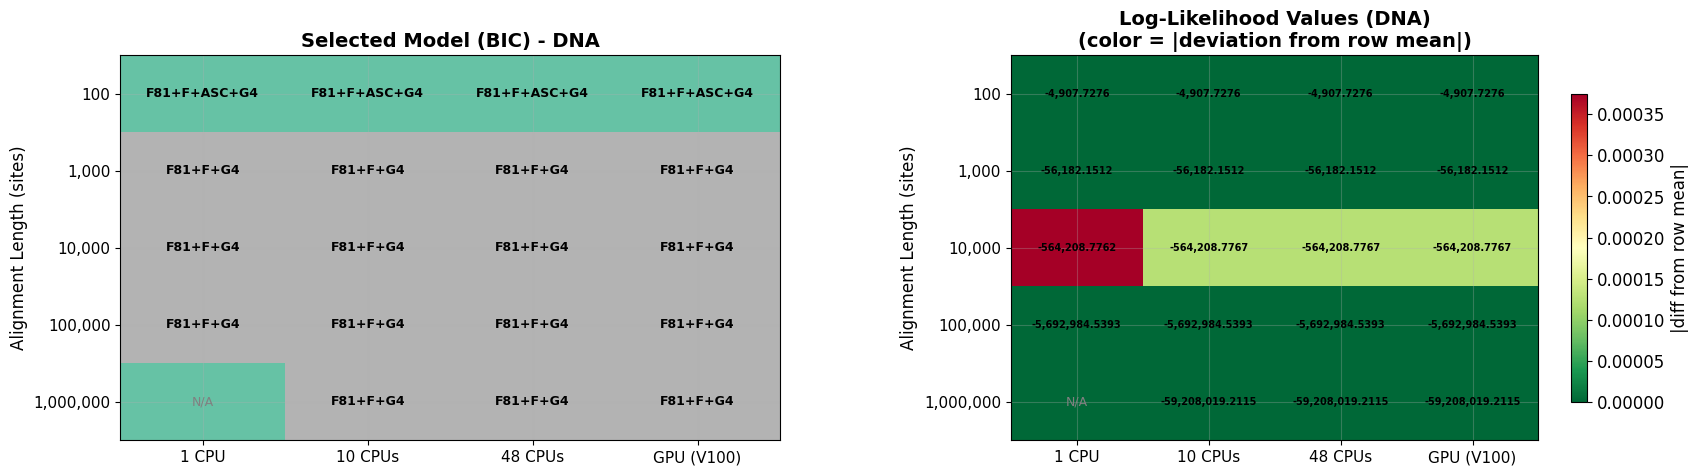

In [10]:
# --- 1. Selected Model Heatmap ---
model_pivot = df.pivot_table(index='length', columns='workflow_label', values='best_model', aggfunc='first')
model_cols = [c for c in wf_order if c in model_pivot.columns]
model_pivot = model_pivot[model_cols]

all_models = sorted(model_pivot.stack().unique())
model_to_int = {m: i for i, m in enumerate(all_models)}
model_numeric = model_pivot.applymap(lambda x: model_to_int.get(x, -1) if pd.notna(x) else -1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

n_models = len(all_models)
cmap = plt.cm.get_cmap('Set2', max(n_models, 2))

im1 = ax1.imshow(model_numeric.values, cmap=cmap, aspect='auto', vmin=-0.5, vmax=n_models-0.5)
ax1.set_xticks(range(len(model_cols)))
ax1.set_xticklabels(model_cols, fontsize=11)
ax1.set_yticks(range(len(model_pivot.index)))
ax1.set_yticklabels([f'{l:,}' for l in model_pivot.index], fontsize=11)
ax1.set_ylabel('Alignment Length (sites)', fontsize=12)
ax1.set_title('Selected Model (BIC) - DNA', fontsize=14, fontweight='bold')

for i in range(len(model_pivot.index)):
    for j in range(len(model_cols)):
        val = model_pivot.iloc[i, j]
        if pd.notna(val):
            ax1.text(j, i, val, ha='center', va='center', fontsize=9, fontweight='bold')
        else:
            ax1.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

# --- 2. Log-Likelihood Heatmap ---
lnl_pivot_full = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_cols = [c for c in wf_order if c in lnl_pivot_full.columns]
lnl_pivot_full = lnl_pivot_full[lnl_cols]

row_means = lnl_pivot_full.mean(axis=1)
lnl_diff_from_mean = lnl_pivot_full.sub(row_means, axis=0).abs()

max_diff = lnl_diff_from_mean.max().max()
if pd.isna(max_diff) or max_diff == 0:
    max_diff = 1.0
norm = mcolors.Normalize(vmin=0, vmax=max_diff)

im2 = ax2.imshow(lnl_diff_from_mean.fillna(0).values, cmap='RdYlGn_r', aspect='auto', norm=norm)
ax2.set_xticks(range(len(lnl_cols)))
ax2.set_xticklabels(lnl_cols, fontsize=11)
ax2.set_yticks(range(len(lnl_pivot_full.index)))
ax2.set_yticklabels([f'{l:,}' for l in lnl_pivot_full.index], fontsize=11)
ax2.set_ylabel('Alignment Length (sites)', fontsize=12)
ax2.set_title('Log-Likelihood Values (DNA)\n(color = |deviation from row mean|)', fontsize=14, fontweight='bold')

for i in range(len(lnl_pivot_full.index)):
    for j in range(len(lnl_cols)):
        val = lnl_pivot_full.iloc[i, j]
        if pd.notna(val):
            txt = f'{val:,.4f}'
            ax2.text(j, i, txt, ha='center', va='center', fontsize=7, fontweight='bold')
        else:
            ax2.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

plt.colorbar(im2, ax=ax2, label='|diff from row mean|', shrink=0.8)
plt.subplots_adjust(wspace=0.35)
plt.savefig(os.path.join(SAVE_DIR, 'model_likelihood_heatmap_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Model Log-Likelihood Comparison (DNA)

In [11]:
# Load per-model data for DNA
dna_lengths = sorted(df_dna['length'].unique())
model_df_dna = load_model_details('DNA', dna_lengths)
print(f"Parsed {len(model_df_dna)} model evaluations across {model_df_dna['length'].nunique()} lengths and {model_df_dna['workflow'].nunique()} workflows")
print(f"Unique models tested: {model_df_dna['model'].nunique()}")

Parsed 1862 model evaluations across 5 lengths and 4 workflows
Unique models tested: 146


In [12]:
# Per-model lnL comparison: compute max |diff| across workflows
lnl_pivot_dna = df_dna.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_pivot_dna = lnl_pivot_dna[[c for c in wf_order if c in lnl_pivot_dna.columns]]

comparison_rows = []
for length in sorted(model_df_dna['length'].unique()):
    len_df = model_df_dna[model_df_dna['length'] == length]
    for model_name in len_df['model'].unique():
        m_df = len_df[len_df['model'] == model_name]
        if len(m_df) < 2:
            continue
        wf_lnl = {}
        for wf in wf_order:
            wf_rows = m_df[m_df['workflow_label'] == wf]
            if len(wf_rows) > 0:
                wf_lnl[wf] = float(wf_rows['lnL'].iloc[0])
        if len(wf_lnl) < 2:
            continue
        vals = list(wf_lnl.values())
        abs_diff = max(vals) - min(vals)
        row = {'length': length, 'model': model_name, 'abs_diff': abs_diff, 'n_workflows': len(wf_lnl)}
        for wf in wf_order:
            row[f'lnL_{wf}'] = wf_lnl.get(wf, float('nan'))
        comparison_rows.append(row)

comp_df_dna = pd.DataFrame(comparison_rows)
comp_df_dna = comp_df_dna[comp_df_dna['n_workflows'] >= 2]

print(f"Compared {len(comp_df_dna)} (model, length) pairs across workflows (DNA)\n")
print("=== Maximum absolute lnL difference across workflows ===")
for length in sorted(comp_df_dna['length'].unique()):
    sub = comp_df_dna[comp_df_dna['length'] == length]
    max_diff = sub['abs_diff'].max()
    mean_diff = sub['abs_diff'].mean()
    n_exact = (sub['abs_diff'] == 0).sum()
    n_total = len(sub)
    worst_model = sub.loc[sub['abs_diff'].idxmax(), 'model'] if max_diff > 0 else 'all identical'
    print(f"  len={length:>10,}: max_diff={max_diff:.4f}  mean_diff={mean_diff:.6f}  exact_match={n_exact}/{n_total}  worst={worst_model}")

print(f"\nOverall max |diff| (DNA): {comp_df_dna['abs_diff'].max():.6f}")
print(f"Overall mean |diff| (DNA): {comp_df_dna['abs_diff'].mean():.8f}")

Compared 380 (model, length) pairs across workflows (DNA)

=== Maximum absolute lnL difference across workflows ===
  len=       100: max_diff=0.0020  mean_diff=0.000028  exact_match=106/108  worst=JC+R4
  len=     1,000: max_diff=0.0200  mean_diff=0.000513  exact_match=71/76  worst=JC+I+R4
  len=    10,000: max_diff=0.0090  mean_diff=0.000461  exact_match=62/76  worst=JC+R5
  len=   100,000: max_diff=0.2080  mean_diff=0.006727  exact_match=42/44  worst=JC+I+R5
  len= 1,000,000: max_diff=0.7300  mean_diff=0.015921  exact_match=70/76  worst=JC+I+R5

Overall max |diff| (DNA): 0.730000
Overall mean |diff| (DNA): 0.00416579


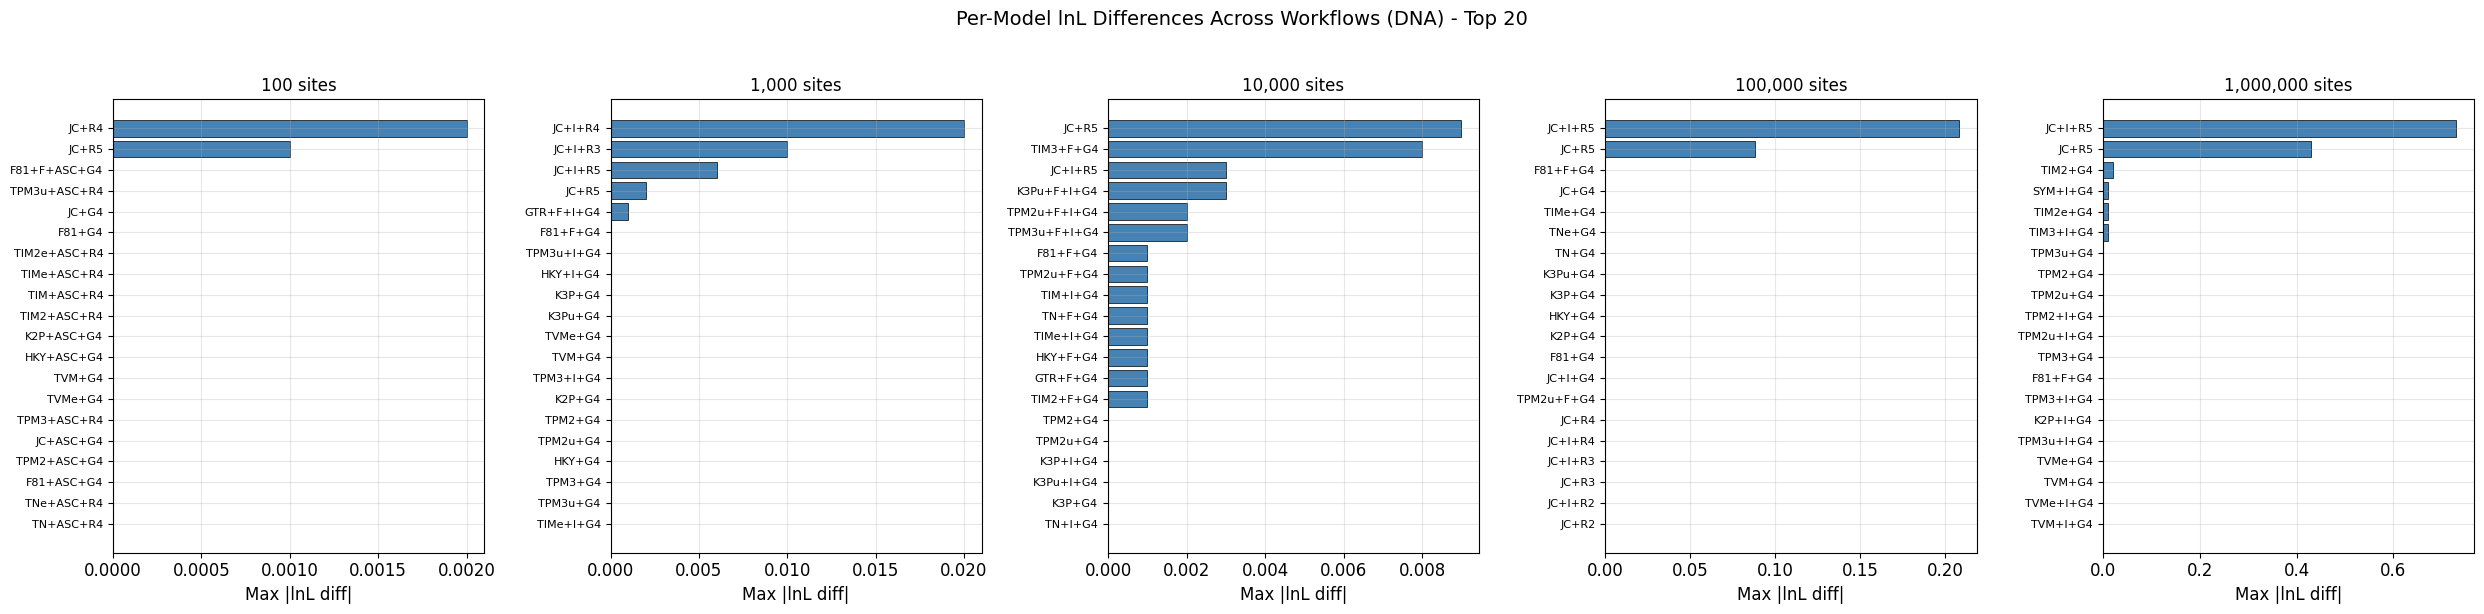

In [13]:
# Per-model lnL difference plot (DNA)
fig, axes = plt.subplots(1, len(comp_df_dna['length'].unique()), figsize=(5*len(comp_df_dna['length'].unique()), 6), sharey=False)
if len(comp_df_dna['length'].unique()) == 1:
    axes = [axes]

for i, length in enumerate(sorted(comp_df_dna['length'].unique())):
    ax = axes[i]
    sub = comp_df_dna[comp_df_dna['length'] == length].sort_values('abs_diff', ascending=False).head(20)
    if len(sub) == 0:
        continue
    ax.barh(range(len(sub)), sub['abs_diff'].values, color='steelblue', edgecolor='black', linewidth=0.5)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['model'].values, fontsize=8)
    ax.set_xlabel('Max |lnL diff|')
    ax.set_title(f'{length:,} sites', fontsize=12)
    ax.invert_yaxis()

fig.suptitle('Per-Model lnL Differences Across Workflows (DNA) - Top 20', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'per_model_lnl_differences_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 4. Wall-Clock Runtime Comparison (DNA)

In [14]:
time_pivot_dna = df_dna.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
time_pivot_dna = time_pivot_dna[[c for c in wf_order if c in time_pivot_dna.columns]]

print('Wall-clock time (seconds) - DNA:')
print(time_pivot_dna.to_string(float_format='%.1f'))
print()
print('Wall-clock time (human-readable) - DNA:')
print(time_pivot_dna.applymap(fmt_time).to_string())

Wall-clock time (seconds) - DNA:
workflow_label  1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                             
100               6.3      5.1    141.3        58.3
1000             24.1      8.7     19.3        33.7
10000           451.0     67.3     55.6        61.0
100000         3544.0    453.2    210.1       118.8
1000000           NaN  15978.7   7880.4      2340.0

Wall-clock time (human-readable) - DNA:
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100              6.3s    5.1s    2.4m      58.3s
1000            24.1s    8.7s   19.3s      33.7s
10000            7.5m    1.1m   55.6s       1.0m
100000          59.1m    7.6m    3.5m       2.0m
1000000           N/A    4.4h    2.2h      39.0m


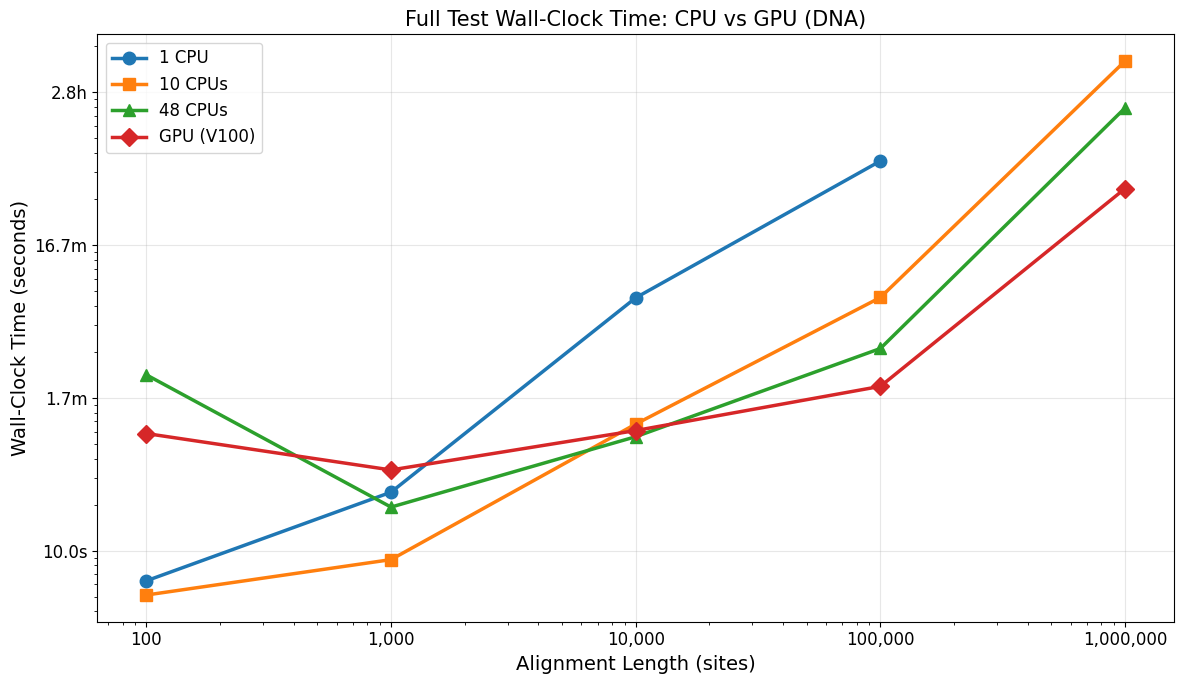

In [15]:
# Wall-clock time plot (DNA)
fig, ax = plt.subplots(figsize=(12, 7))
available_wfs = [c for c in wf_order if c in time_pivot_dna.columns]

for wf in available_wfs:
    data = time_pivot_dna[wf].dropna()
    ax.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Alignment Length (sites)', fontsize=14)
ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=14)
ax.set_title('Full Test Wall-Clock Time: CPU vs GPU (DNA)', fontsize=15)
ax.legend(fontsize=12, loc='upper left')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: fmt_time(x)))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

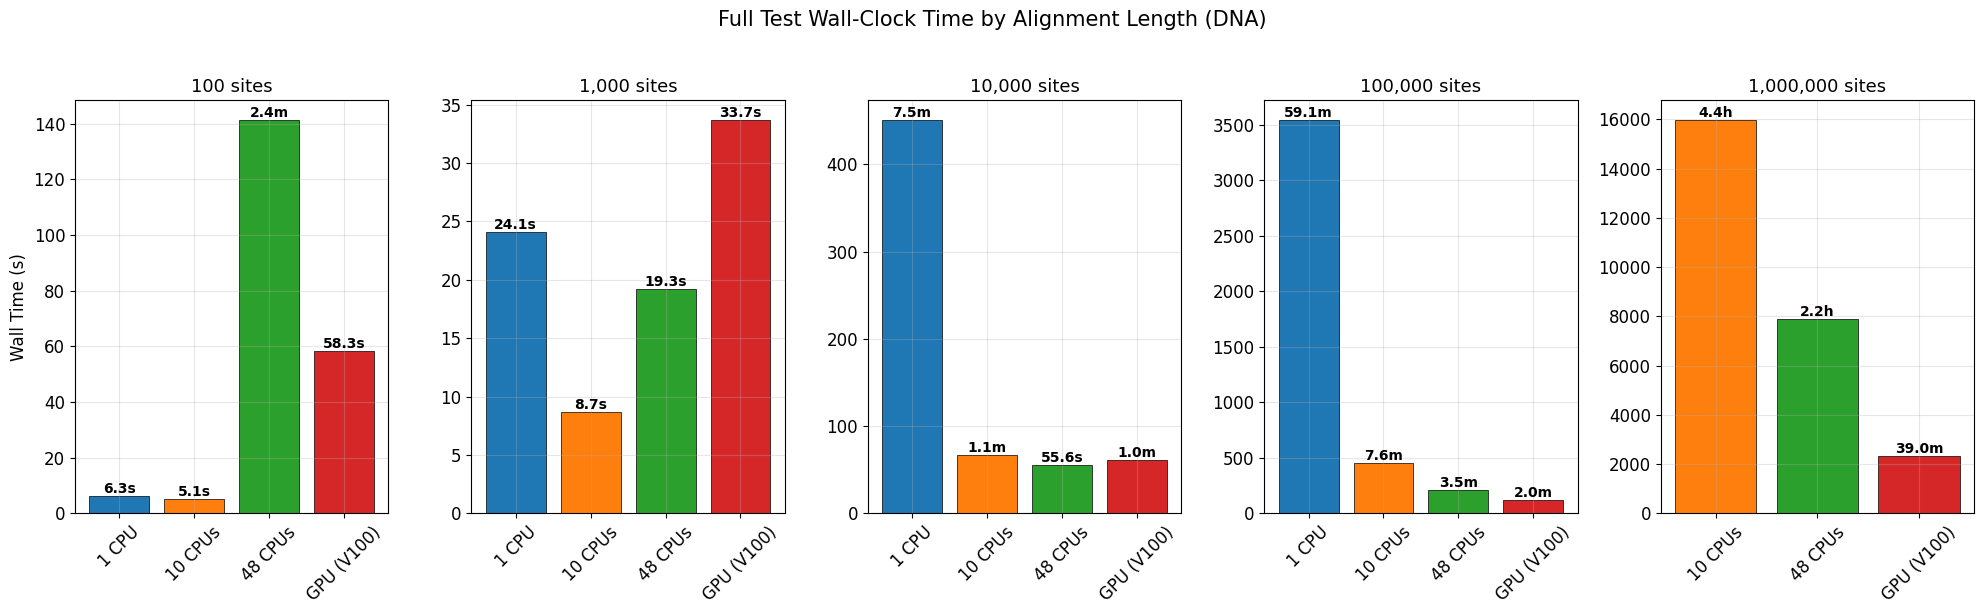

In [16]:
# Bar chart for wall-clock time at each alignment length (DNA)
valid_lengths = time_pivot_dna.dropna(thresh=2).index

fig, axes = plt.subplots(1, len(valid_lengths), figsize=(4*len(valid_lengths), 6), sharey=False)
if len(valid_lengths) == 1:
    axes = [axes]

for i, length in enumerate(valid_lengths):
    ax = axes[i]
    vals = []
    labels = []
    bar_colors = []
    for wf in available_wfs:
        v = time_pivot_dna.loc[length, wf]
        if not pd.isna(v):
            vals.append(v)
            labels.append(wf)
            bar_colors.append(colors[wf])
    
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{length:,} sites', fontsize=13)
    ax.set_ylabel('Wall Time (s)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Full Test Wall-Clock Time by Alignment Length (DNA)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_bars_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Speedup Analysis (DNA)

In [17]:
if '1 CPU' in time_pivot_dna.columns:
    speedup_df_dna = pd.DataFrame(index=time_pivot_dna.index)
    for wf in available_wfs:
        speedup_df_dna[wf] = time_pivot_dna['1 CPU'] / time_pivot_dna[wf]
    
    print('Speedup vs 1 CPU (wall-clock) - DNA:')
    print(speedup_df_dna.to_string(float_format='%.2f'))
    print()
    
    if 'GPU (V100)' in time_pivot_dna.columns and '48 CPUs' in time_pivot_dna.columns:
        gpu_vs_48 = time_pivot_dna['48 CPUs'] / time_pivot_dna['GPU (V100)']
        print('GPU speedup vs 48 CPUs (DNA):')
        for length in gpu_vs_48.dropna().index:
            val = gpu_vs_48[length]
            direction = f'{val:.2f}x faster' if val >= 1 else f'{1/val:.2f}x slower'
            print(f'  len={length:>10,}: {direction}')

Speedup vs 1 CPU (wall-clock) - DNA:
         1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                      
100       1.00     1.24     0.04        0.11
1000      1.00     2.76     1.25        0.72
10000     1.00     6.70     8.11        7.39
100000    1.00     7.82    16.87       29.84
1000000    NaN      NaN      NaN         NaN

GPU speedup vs 48 CPUs (DNA):
  len=       100: 2.42x faster
  len=     1,000: 1.75x slower
  len=    10,000: 1.10x slower
  len=   100,000: 1.77x faster
  len= 1,000,000: 3.37x faster


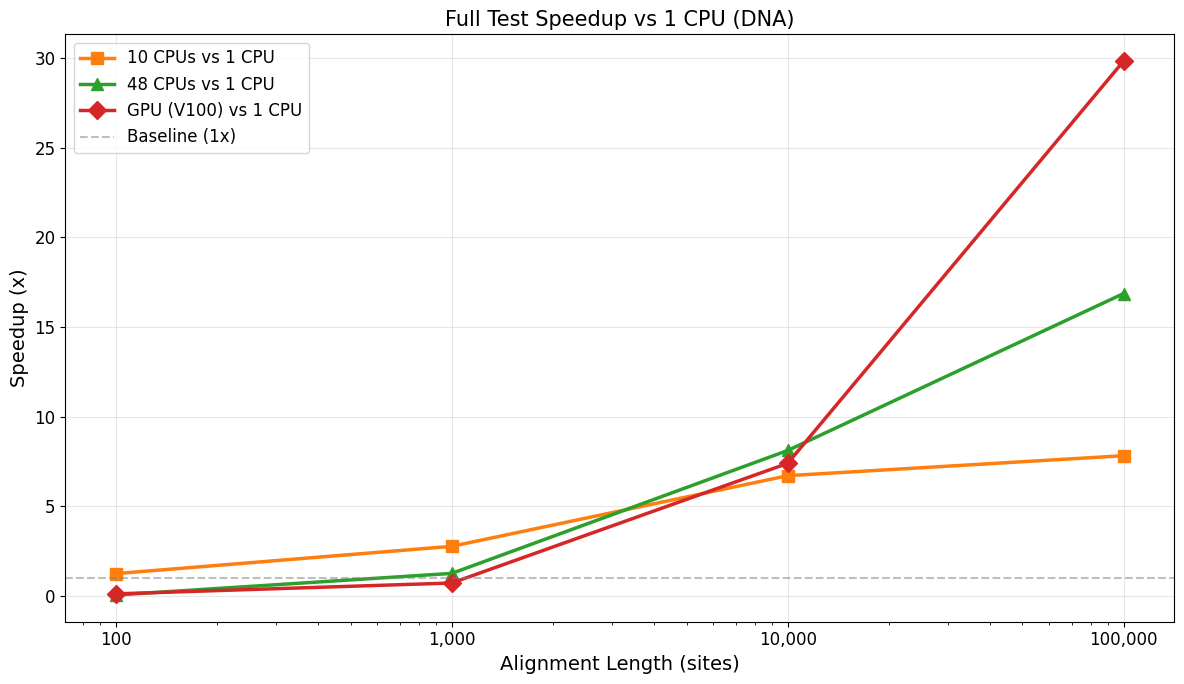

In [18]:
# Speedup plot (DNA)
if '1 CPU' in time_pivot_dna.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for wf in available_wfs:
        if wf == '1 CPU':
            continue
        data = speedup_df_dna[wf].dropna()
        ax.plot(data.index, data.values, marker=markers[wf], label=f'{wf} vs 1 CPU',
                color=colors[wf], linewidth=2.5, markersize=9)
    
    ax.set_xscale('log')
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline (1x)')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Speedup (x)', fontsize=14)
    ax.set_title('Full Test Speedup vs 1 CPU (DNA)', fontsize=15)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_vs_1cpu_DNA.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 6. CPU Time (Total Compute) Comparison (DNA)

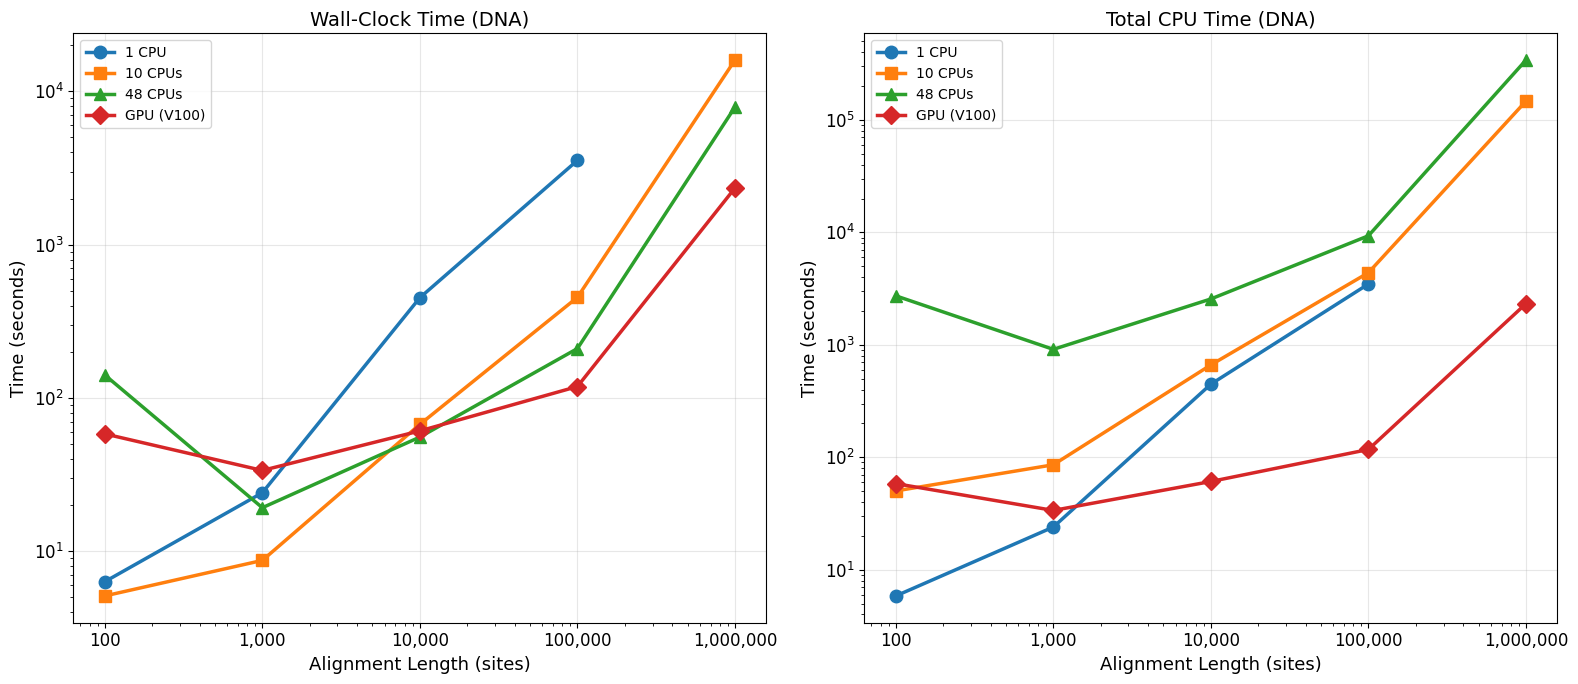

In [19]:
cpu_pivot_dna = df_dna.pivot_table(index='length', columns='workflow_label', values='cpu_time_sec', aggfunc='first')
cpu_pivot_dna = cpu_pivot_dna[[c for c in wf_order if c in cpu_pivot_dna.columns]]

# CPU time vs wall time comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Left: Wall-clock time
for wf in available_wfs:
    data = time_pivot_dna[wf].dropna()
    ax1.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length (sites)', fontsize=13)
ax1.set_ylabel('Time (seconds)', fontsize=13)
ax1.set_title('Wall-Clock Time (DNA)', fontsize=14)
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Right: Total CPU time
for wf in [c for c in wf_order if c in cpu_pivot_dna.columns]:
    data = cpu_pivot_dna[wf].dropna()
    ax2.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length (sites)', fontsize=13)
ax2.set_ylabel('Time (seconds)', fontsize=13)
ax2.set_title('Total CPU Time (DNA)', fontsize=14)
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_vs_cpu_time_DNA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. BIC / AIC Score Comparison (DNA)

In [20]:
if 'bic' in df_dna.columns:
    bic_pivot = df_dna.pivot_table(index='length', columns='workflow_label', values='bic', aggfunc='first')
    bic_pivot = bic_pivot[[c for c in wf_order if c in bic_pivot.columns]]
    print('BIC scores (DNA):')
    print(bic_pivot.to_string(float_format='%.2f'))
    print()
    
    # BIC differences from row mean
    bic_diff = bic_pivot.sub(bic_pivot.mean(axis=1), axis=0)
    print('BIC deviation from row mean (DNA):')
    print(bic_diff.to_string(float_format='%.4f'))

if 'aic' in df_dna.columns:
    aic_pivot = df_dna.pivot_table(index='length', columns='workflow_label', values='aic', aggfunc='first')
    aic_pivot = aic_pivot[[c for c in wf_order if c in aic_pivot.columns]]
    print('\nAIC scores (DNA):')
    print(aic_pivot.to_string(float_format='%.2f'))

BIC scores (DNA):
workflow_label       1 CPU      10 CPUs      48 CPUs   GPU (V100)
length                                                           
100               10741.09     10741.09     10741.09     10741.09
1000             113752.76    113752.76    113752.76    113752.76
10000           1130268.83   1130268.83   1130268.83   1130268.83
100000         11388283.18  11388283.18  11388283.18  11388283.18
1000000                NaN 118418815.34 118418815.34 118418815.34

BIC deviation from row mean (DNA):
workflow_label   1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                              
100             0.0000   0.0000   0.0000      0.0000
1000            0.0000   0.0000   0.0000      0.0000
10000          -0.0008   0.0003   0.0003      0.0003
100000          0.0000   0.0000   0.0000      0.0000
1000000            NaN   0.0000   0.0000      0.0000

AIC scores (DNA):
workflow_label       1 CPU      10 CPUs      48 CPUs   GPU (V100)
length                      

## 8. Summary: GPU vs CPU (DNA)

In [21]:
if 'GPU (V100)' in time_pivot_dna.columns:
    summary_rows = []
    for length in time_pivot_dna.index:
        gpu_time = time_pivot_dna.loc[length, 'GPU (V100)']
        if pd.isna(gpu_time):
            continue
        row = {'Sites': f'{length:,}'}
        row['GPU Wall Time'] = fmt_time(gpu_time)
        
        for wf in ['1 CPU', '10 CPUs', '48 CPUs']:
            if wf in time_pivot_dna.columns:
                cpu_time = time_pivot_dna.loc[length, wf]
                if not pd.isna(cpu_time):
                    row[f'{wf} Wall Time'] = fmt_time(cpu_time)
                    speedup = cpu_time / gpu_time
                    row[f'GPU vs {wf}'] = f'{speedup:.2f}x' if speedup >= 1 else f'{1/speedup:.2f}x slower'
        
        gpu_lnl = lnl_pivot_dna.loc[length, 'GPU (V100)'] if 'GPU (V100)' in lnl_pivot_dna.columns else None
        cpu_lnl = lnl_pivot_dna.loc[length, '1 CPU'] if '1 CPU' in lnl_pivot_dna.columns else None
        if gpu_lnl is not None and cpu_lnl is not None and not pd.isna(gpu_lnl) and not pd.isna(cpu_lnl):
            row['lnL Match'] = f'delta={abs(gpu_lnl - cpu_lnl):.6f}'
        
        summary_rows.append(row)
    
    summary_df_dna = pd.DataFrame(summary_rows)
    print('=' * 110)
    print('SUMMARY: GPU (V100) vs CPU Workflows - DNA (Full Test)')
    print('=' * 110)
    print(summary_df_dna.to_string(index=False))

SUMMARY: GPU (V100) vs CPU Workflows - DNA (Full Test)
    Sites GPU Wall Time 1 CPU Wall Time GPU vs 1 CPU 10 CPUs Wall Time GPU vs 10 CPUs 48 CPUs Wall Time GPU vs 48 CPUs      lnL Match
      100         58.3s            6.3s 9.20x slower              5.1s  11.40x slower              2.4m          2.42x delta=0.000000
    1,000         33.7s           24.1s 1.40x slower              8.7s   3.86x slower             19.3s   1.75x slower delta=0.000000
   10,000          1.0m            7.5m        7.39x              1.1m          1.10x             55.6s   1.10x slower delta=0.000500
  100,000          2.0m           59.1m       29.84x              7.6m          3.82x              3.5m          1.77x delta=0.000000
1,000,000         39.0m             NaN          NaN              4.4h          6.83x              2.2h          3.37x            NaN


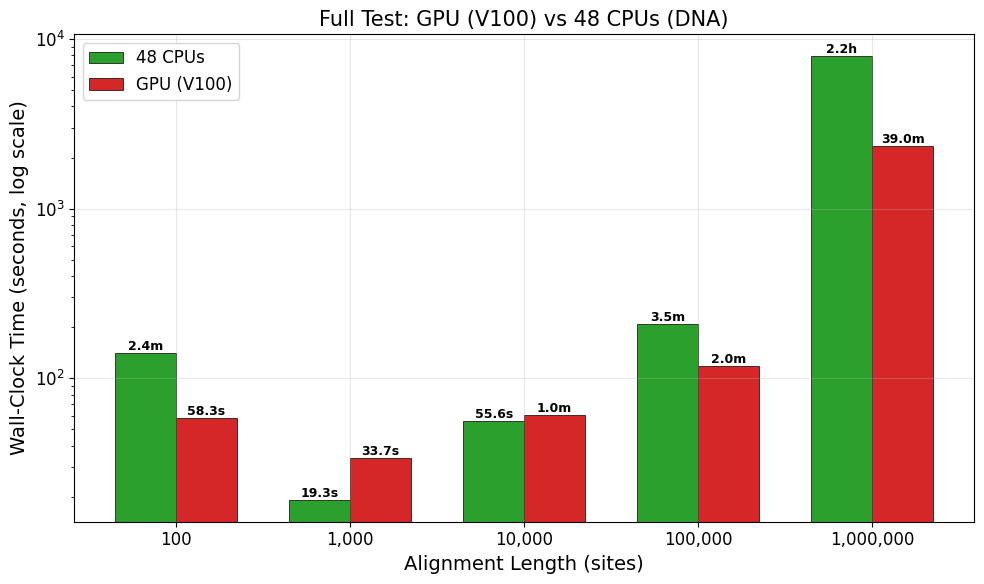

In [22]:
# GPU vs 48 CPUs bar chart (DNA)
if 'GPU (V100)' in time_pivot_dna.columns and '48 CPUs' in time_pivot_dna.columns:
    common_idx = time_pivot_dna[['GPU (V100)', '48 CPUs']].dropna().index
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x_labels = [f'{l:,}' for l in common_idx]
    gpu_times = [time_pivot_dna.loc[l, 'GPU (V100)'] for l in common_idx]
    cpu48_times = [time_pivot_dna.loc[l, '48 CPUs'] for l in common_idx]
    
    x = np.arange(len(x_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cpu48_times, width, label='48 CPUs', color=colors['48 CPUs'], edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, gpu_times, width, label='GPU (V100)', color=colors['GPU (V100)'], edgecolor='black', linewidth=0.5)
    
    for bar, v in zip(bars1, cpu48_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar, v in zip(bars2, gpu_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Wall-Clock Time (seconds, log scale)', fontsize=14)
    ax.set_title('Full Test: GPU (V100) vs 48 CPUs (DNA)', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gpu_vs_48cpu_bars_DNA.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 2: Amino Acid Analysis (LG+I+G4)

## 9. Model Selection Agreement (AA)

In [23]:
df = df_aa.copy()

model_pivot_aa = df.pivot_table(index='length', columns='workflow_label', values='best_model', aggfunc='first')
model_cols_aa = [c for c in wf_order if c in model_pivot_aa.columns]
model_pivot_aa = model_pivot_aa[model_cols_aa]

print('Selected model per workflow (AA):')
print(model_pivot_aa.to_string())
print()

for length in model_pivot_aa.index:
    models = model_pivot_aa.loc[length].dropna().unique()
    status = 'AGREE' if len(models) == 1 else 'DISAGREE'
    print(f'  len={length:>10,}: {status} -> {list(models)}')

Selected model per workflow (AA):
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100             LG+G4   LG+G4   LG+G4      LG+G4
1000            LG+G4   LG+G4   LG+G4      LG+G4
10000           LG+G4   LG+G4   LG+G4      LG+G4
100000            NaN   LG+G4   LG+G4      LG+G4

  len=       100: AGREE -> ['LG+G4']
  len=     1,000: AGREE -> ['LG+G4']
  len=    10,000: AGREE -> ['LG+G4']
  len=   100,000: AGREE -> ['LG+G4']


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_62167/4218021727.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap('Set2', max(n_models, 2))


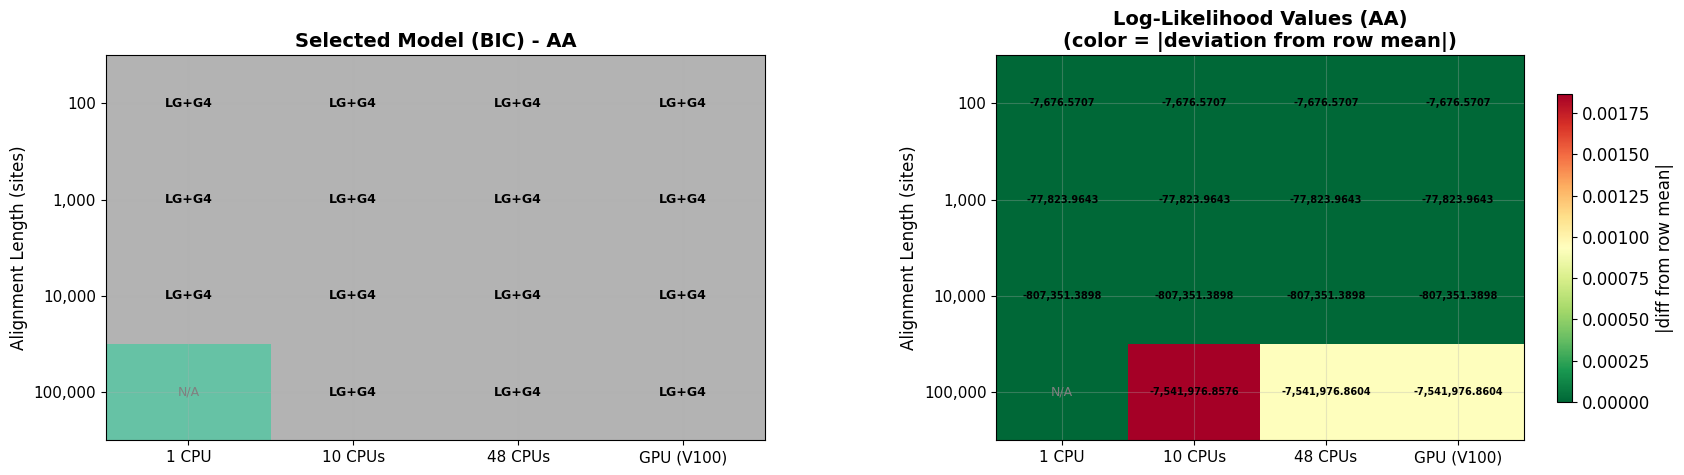

In [24]:
# Model Selection & Log-Likelihood Heatmap (AA)
model_pivot = df.pivot_table(index='length', columns='workflow_label', values='best_model', aggfunc='first')
model_cols = [c for c in wf_order if c in model_pivot.columns]
model_pivot = model_pivot[model_cols]

all_models = sorted(model_pivot.stack().unique())
model_to_int = {m: i for i, m in enumerate(all_models)}
model_numeric = model_pivot.applymap(lambda x: model_to_int.get(x, -1) if pd.notna(x) else -1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))

n_models = len(all_models)
cmap = plt.cm.get_cmap('Set2', max(n_models, 2))

im1 = ax1.imshow(model_numeric.values, cmap=cmap, aspect='auto', vmin=-0.5, vmax=n_models-0.5)
ax1.set_xticks(range(len(model_cols)))
ax1.set_xticklabels(model_cols, fontsize=11)
ax1.set_yticks(range(len(model_pivot.index)))
ax1.set_yticklabels([f'{l:,}' for l in model_pivot.index], fontsize=11)
ax1.set_ylabel('Alignment Length (sites)', fontsize=12)
ax1.set_title('Selected Model (BIC) - AA', fontsize=14, fontweight='bold')

for i in range(len(model_pivot.index)):
    for j in range(len(model_cols)):
        val = model_pivot.iloc[i, j]
        if pd.notna(val):
            ax1.text(j, i, val, ha='center', va='center', fontsize=9, fontweight='bold')
        else:
            ax1.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

lnl_pivot_aa_full = df.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_cols = [c for c in wf_order if c in lnl_pivot_aa_full.columns]
lnl_pivot_aa_full = lnl_pivot_aa_full[lnl_cols]

row_means = lnl_pivot_aa_full.mean(axis=1)
lnl_diff_from_mean = lnl_pivot_aa_full.sub(row_means, axis=0).abs()

max_diff = lnl_diff_from_mean.max().max()
if pd.isna(max_diff) or max_diff == 0:
    max_diff = 1.0
norm = mcolors.Normalize(vmin=0, vmax=max_diff)

im2 = ax2.imshow(lnl_diff_from_mean.fillna(0).values, cmap='RdYlGn_r', aspect='auto', norm=norm)
ax2.set_xticks(range(len(lnl_cols)))
ax2.set_xticklabels(lnl_cols, fontsize=11)
ax2.set_yticks(range(len(lnl_pivot_aa_full.index)))
ax2.set_yticklabels([f'{l:,}' for l in lnl_pivot_aa_full.index], fontsize=11)
ax2.set_ylabel('Alignment Length (sites)', fontsize=12)
ax2.set_title('Log-Likelihood Values (AA)\n(color = |deviation from row mean|)', fontsize=14, fontweight='bold')

for i in range(len(lnl_pivot_aa_full.index)):
    for j in range(len(lnl_cols)):
        val = lnl_pivot_aa_full.iloc[i, j]
        if pd.notna(val):
            txt = f'{val:,.4f}'
            ax2.text(j, i, txt, ha='center', va='center', fontsize=7, fontweight='bold')
        else:
            ax2.text(j, i, 'N/A', ha='center', va='center', fontsize=9, color='gray')

plt.colorbar(im2, ax=ax2, label='|diff from row mean|', shrink=0.8)
plt.subplots_adjust(wspace=0.35)
plt.savefig(os.path.join(SAVE_DIR, 'model_likelihood_heatmap_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. Per-Model Log-Likelihood Comparison (AA)

In [25]:
aa_lengths = sorted(df_aa['length'].unique())
model_df_aa = load_model_details('AA', aa_lengths)
print(f"Parsed {len(model_df_aa)} model evaluations across {model_df_aa['length'].nunique()} lengths and {model_df_aa['workflow'].nunique()} workflows")
print(f"Unique models tested: {model_df_aa['model'].nunique()}")

Parsed 1665 model evaluations across 4 lengths and 4 workflows
Unique models tested: 122


In [26]:
lnl_pivot_aa = df_aa.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
lnl_pivot_aa = lnl_pivot_aa[[c for c in wf_order if c in lnl_pivot_aa.columns]]

comparison_rows_aa = []
for length in sorted(model_df_aa['length'].unique()):
    len_df = model_df_aa[model_df_aa['length'] == length]
    for model_name in len_df['model'].unique():
        m_df = len_df[len_df['model'] == model_name]
        if len(m_df) < 2:
            continue
        wf_lnl = {}
        for wf in wf_order:
            wf_rows = m_df[m_df['workflow_label'] == wf]
            if len(wf_rows) > 0:
                wf_lnl[wf] = float(wf_rows['lnL'].iloc[0])
        if len(wf_lnl) < 2:
            continue
        vals = list(wf_lnl.values())
        abs_diff = max(vals) - min(vals)
        row = {'length': length, 'model': model_name, 'abs_diff': abs_diff, 'n_workflows': len(wf_lnl)}
        for wf in wf_order:
            row[f'lnL_{wf}'] = wf_lnl.get(wf, float('nan'))
        comparison_rows_aa.append(row)

comp_df_aa = pd.DataFrame(comparison_rows_aa)
comp_df_aa = comp_df_aa[comp_df_aa['n_workflows'] >= 2]

print(f"Compared {len(comp_df_aa)} (model, length) pairs across workflows (AA)\n")
print("=== Maximum absolute lnL difference across workflows ===")
for length in sorted(comp_df_aa['length'].unique()):
    sub = comp_df_aa[comp_df_aa['length'] == length]
    max_diff = sub['abs_diff'].max()
    mean_diff = sub['abs_diff'].mean()
    n_exact = (sub['abs_diff'] == 0).sum()
    n_total = len(sub)
    worst_model = sub.loc[sub['abs_diff'].idxmax(), 'model'] if max_diff > 0 else 'all identical'
    print(f"  len={length:>10,}: max_diff={max_diff:.4f}  mean_diff={mean_diff:.6f}  exact_match={n_exact}/{n_total}  worst={worst_model}")

print(f"\nOverall max |diff| (AA): {comp_df_aa['abs_diff'].max():.6f}")
print(f"Overall mean |diff| (AA): {comp_df_aa['abs_diff'].mean():.8f}")

Compared 433 (model, length) pairs across workflows (AA)

=== Maximum absolute lnL difference across workflows ===
  len=       100: max_diff=0.0010  mean_diff=0.000033  exact_match=118/122  worst=LG+R4
  len=     1,000: max_diff=0.0040  mean_diff=0.000098  exact_match=114/122  worst=LG+I+R5
  len=    10,000: max_diff=0.0110  mean_diff=0.000451  exact_match=104/122  worst=Q.BIRD+I+G4
  len=   100,000: max_diff=0.2120  mean_diff=0.005806  exact_match=56/67  worst=LG+I+R5

Overall max |diff| (AA): 0.212000
Overall mean |diff| (AA): 0.00106236


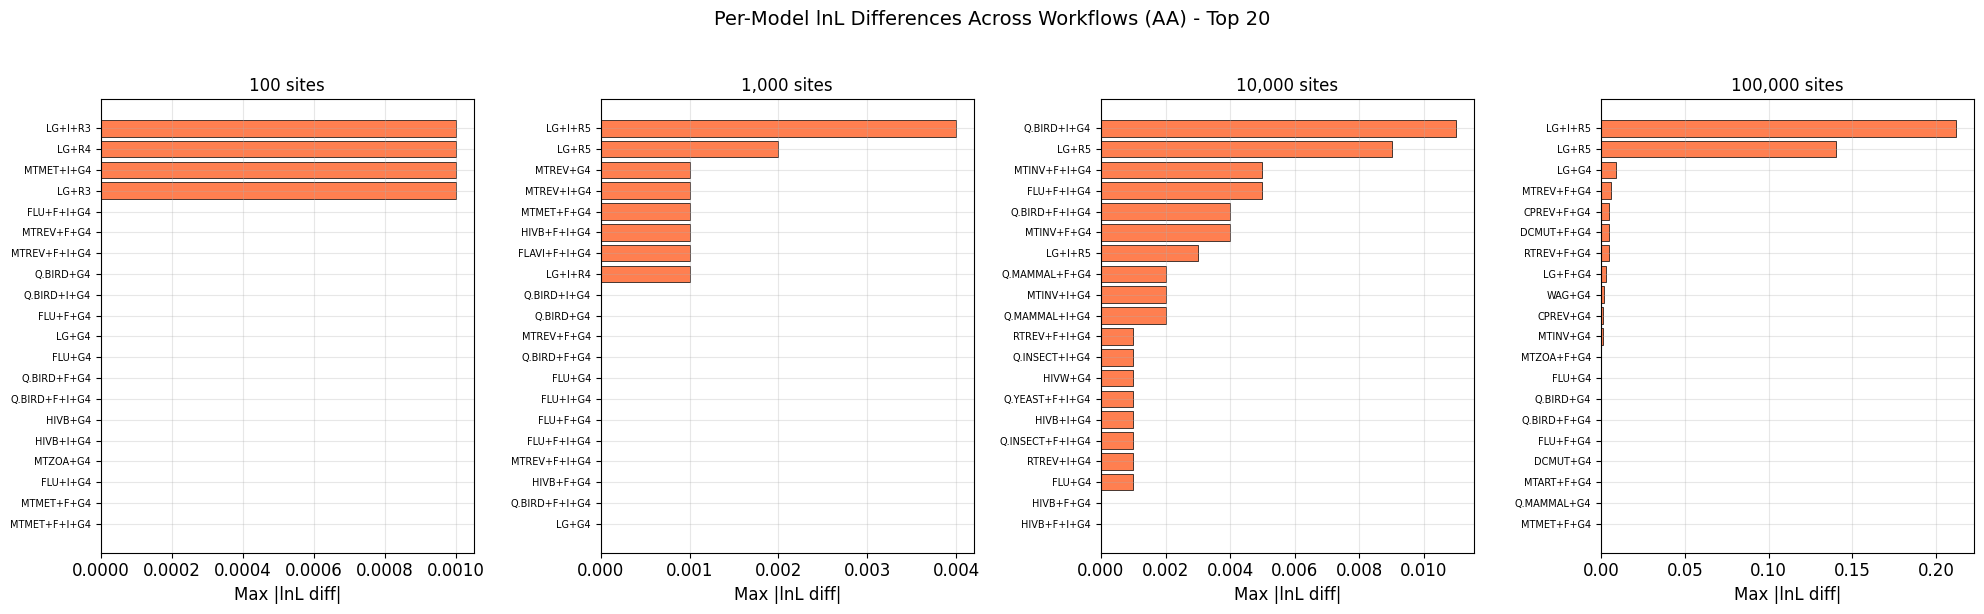

In [27]:
# Per-model lnL difference plot (AA)
n_lengths = comp_df_aa['length'].nunique()
if n_lengths > 0:
    fig, axes = plt.subplots(1, n_lengths, figsize=(5*n_lengths, 6), sharey=False)
    if n_lengths == 1:
        axes = [axes]
    
    for i, length in enumerate(sorted(comp_df_aa['length'].unique())):
        ax = axes[i]
        sub = comp_df_aa[comp_df_aa['length'] == length].sort_values('abs_diff', ascending=False).head(20)
        if len(sub) == 0:
            continue
        ax.barh(range(len(sub)), sub['abs_diff'].values, color='coral', edgecolor='black', linewidth=0.5)
        ax.set_yticks(range(len(sub)))
        ax.set_yticklabels(sub['model'].values, fontsize=7)
        ax.set_xlabel('Max |lnL diff|')
        ax.set_title(f'{length:,} sites', fontsize=12)
        ax.invert_yaxis()
    
    fig.suptitle('Per-Model lnL Differences Across Workflows (AA) - Top 20', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'per_model_lnl_differences_AA.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 11. Wall-Clock Runtime Comparison (AA)

In [28]:
time_pivot_aa = df_aa.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
time_pivot_aa = time_pivot_aa[[c for c in wf_order if c in time_pivot_aa.columns]]

print('Wall-clock time (seconds) - AA:')
print(time_pivot_aa.to_string(float_format='%.1f'))
print()
print('Wall-clock time (human-readable) - AA:')
print(time_pivot_aa.applymap(fmt_time).to_string())

Wall-clock time (seconds) - AA:
workflow_label  1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                             
100              51.6     17.2     16.0        95.6
1000            552.8     70.7     51.0       137.4
10000          5908.6    580.7    217.8       227.5
100000            NaN   4760.5   1392.3       960.9

Wall-clock time (human-readable) - AA:
workflow_label  1 CPU 10 CPUs 48 CPUs GPU (V100)
length                                          
100             51.6s   17.2s   16.0s       1.6m
1000             9.2m    1.2m   51.0s       2.3m
10000            1.6h    9.7m    3.6m       3.8m
100000            N/A    1.3h   23.2m      16.0m


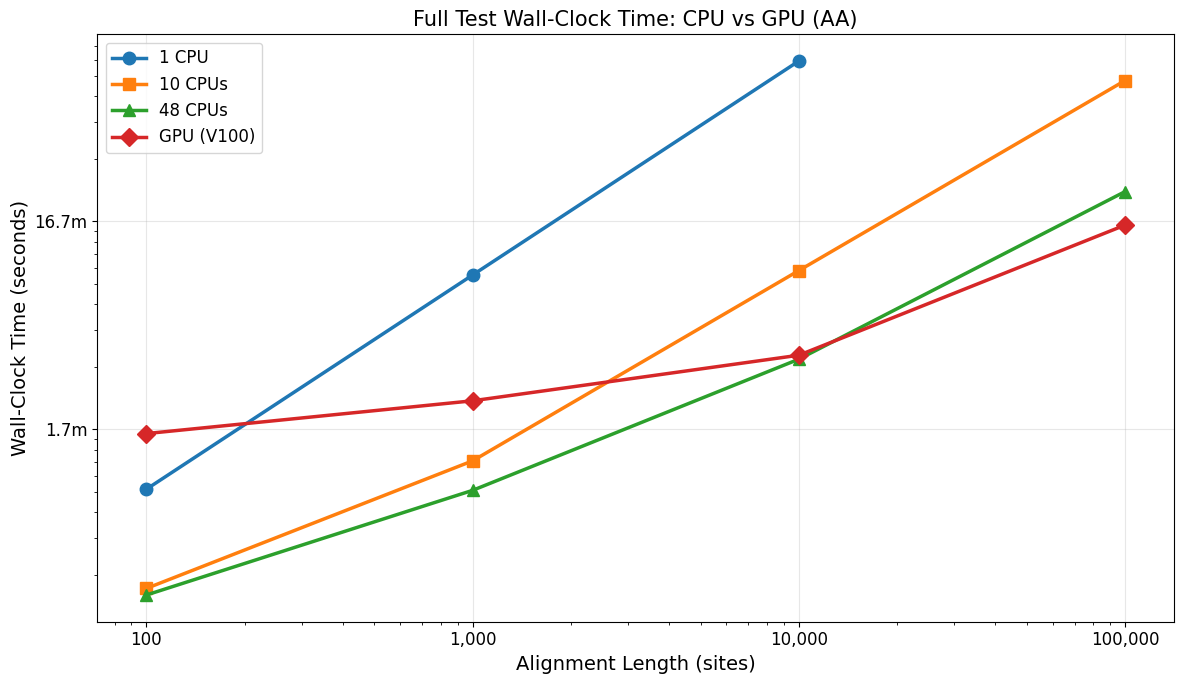

In [29]:
# Wall-clock time plot (AA)
fig, ax = plt.subplots(figsize=(12, 7))
available_wfs_aa = [c for c in wf_order if c in time_pivot_aa.columns]

for wf in available_wfs_aa:
    data = time_pivot_aa[wf].dropna()
    ax.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Alignment Length (sites)', fontsize=14)
ax.set_ylabel('Wall-Clock Time (seconds)', fontsize=14)
ax.set_title('Full Test Wall-Clock Time: CPU vs GPU (AA)', fontsize=15)
ax.legend(fontsize=12, loc='upper left')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: fmt_time(x)))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_comparison_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

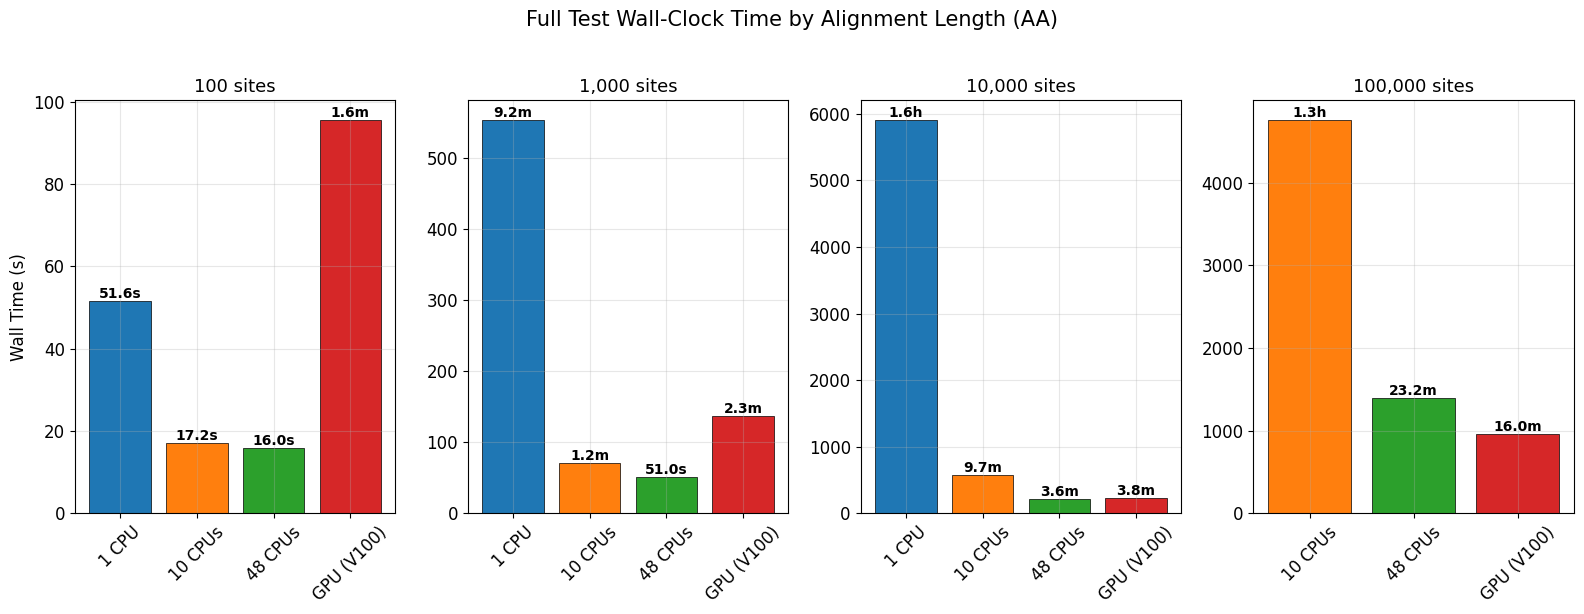

In [30]:
# Bar chart for wall-clock time (AA)
valid_lengths_aa = time_pivot_aa.dropna(thresh=2).index

fig, axes = plt.subplots(1, len(valid_lengths_aa), figsize=(4*len(valid_lengths_aa), 6), sharey=False)
if len(valid_lengths_aa) == 1:
    axes = [axes]

for i, length in enumerate(valid_lengths_aa):
    ax = axes[i]
    vals = []
    labels = []
    bar_colors = []
    for wf in available_wfs_aa:
        v = time_pivot_aa.loc[length, wf]
        if not pd.isna(v):
            vals.append(v)
            labels.append(wf)
            bar_colors.append(colors[wf])
    
    bars = ax.bar(labels, vals, color=bar_colors, edgecolor='black', linewidth=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_title(f'{length:,} sites', fontsize=13)
    ax.set_ylabel('Wall Time (s)' if i == 0 else '')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Full Test Wall-Clock Time by Alignment Length (AA)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_bars_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Speedup Analysis (AA)

In [31]:
if '1 CPU' in time_pivot_aa.columns:
    speedup_df_aa = pd.DataFrame(index=time_pivot_aa.index)
    for wf in available_wfs_aa:
        speedup_df_aa[wf] = time_pivot_aa['1 CPU'] / time_pivot_aa[wf]
    
    print('Speedup vs 1 CPU (wall-clock) - AA:')
    print(speedup_df_aa.to_string(float_format='%.2f'))
    print()
    
    if 'GPU (V100)' in time_pivot_aa.columns and '48 CPUs' in time_pivot_aa.columns:
        gpu_vs_48_aa = time_pivot_aa['48 CPUs'] / time_pivot_aa['GPU (V100)']
        print('GPU speedup vs 48 CPUs (AA):')
        for length in gpu_vs_48_aa.dropna().index:
            val = gpu_vs_48_aa[length]
            direction = f'{val:.2f}x faster' if val >= 1 else f'{1/val:.2f}x slower'
            print(f'  len={length:>10,}: {direction}')

Speedup vs 1 CPU (wall-clock) - AA:
        1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                     
100      1.00     3.00     3.23        0.54
1000     1.00     7.82    10.85        4.02
10000    1.00    10.17    27.13       25.97
100000    NaN      NaN      NaN         NaN

GPU speedup vs 48 CPUs (AA):
  len=       100: 5.97x slower
  len=     1,000: 2.70x slower
  len=    10,000: 1.04x slower
  len=   100,000: 1.45x faster


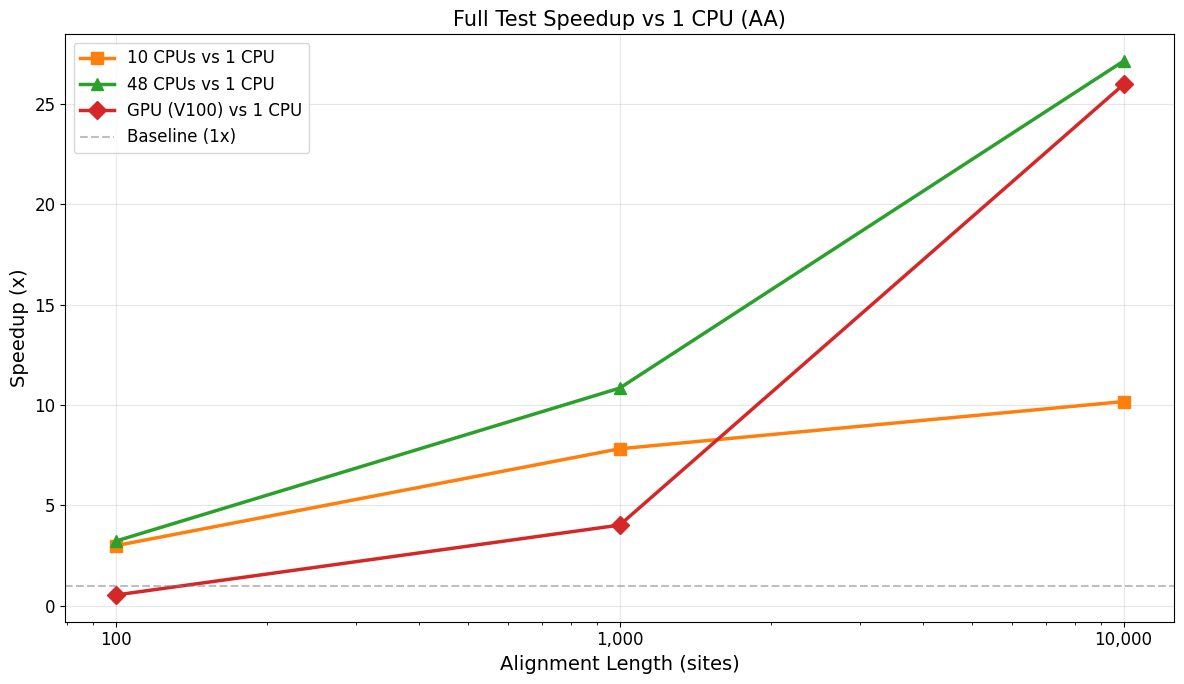

In [32]:
# Speedup plot (AA)
if '1 CPU' in time_pivot_aa.columns:
    fig, ax = plt.subplots(figsize=(12, 7))
    
    for wf in available_wfs_aa:
        if wf == '1 CPU':
            continue
        data = speedup_df_aa[wf].dropna()
        ax.plot(data.index, data.values, marker=markers[wf], label=f'{wf} vs 1 CPU',
                color=colors[wf], linewidth=2.5, markersize=9)
    
    ax.set_xscale('log')
    ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='Baseline (1x)')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Speedup (x)', fontsize=14)
    ax.set_title('Full Test Speedup vs 1 CPU (AA)', fontsize=15)
    ax.legend(fontsize=12)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'speedup_vs_1cpu_AA.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 13. CPU Time Comparison (AA)

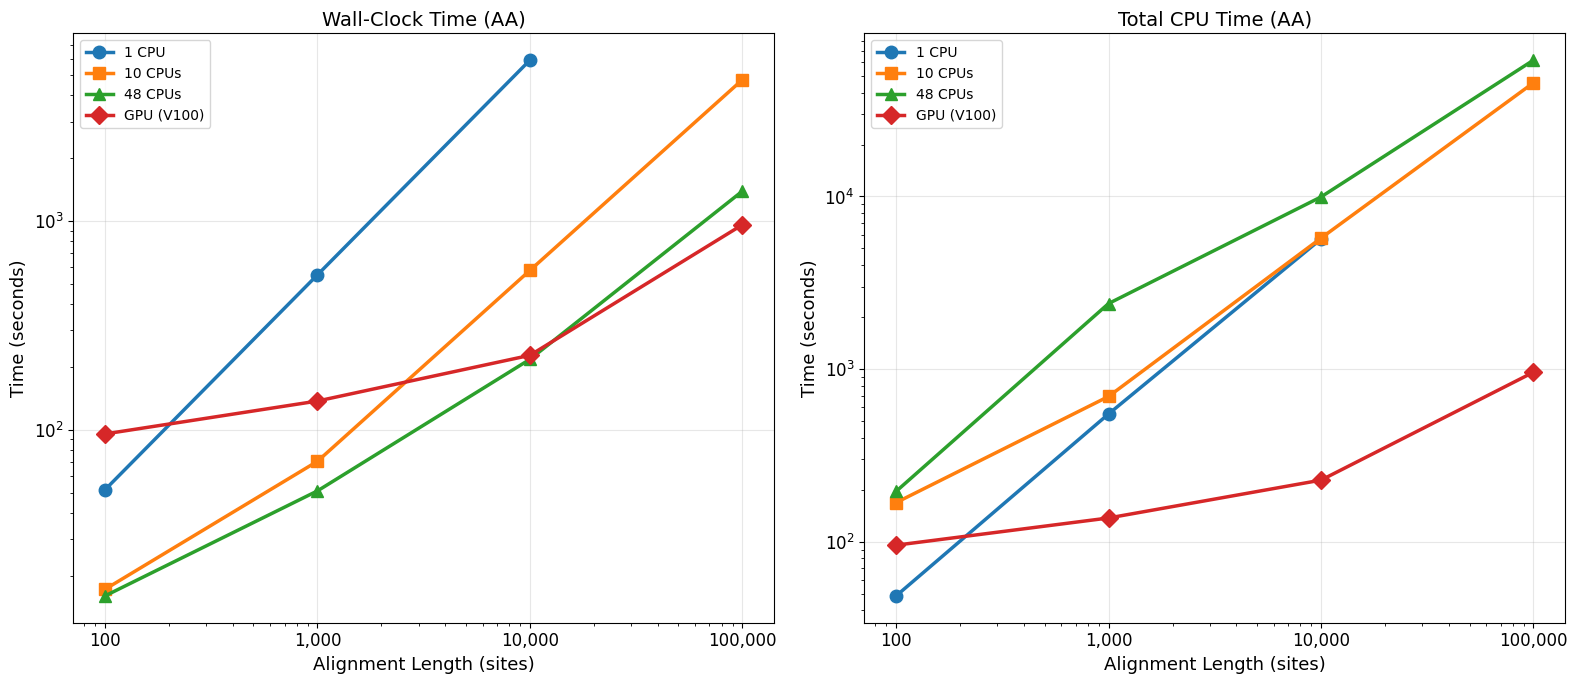

In [33]:
cpu_pivot_aa = df_aa.pivot_table(index='length', columns='workflow_label', values='cpu_time_sec', aggfunc='first')
cpu_pivot_aa = cpu_pivot_aa[[c for c in wf_order if c in cpu_pivot_aa.columns]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for wf in available_wfs_aa:
    data = time_pivot_aa[wf].dropna()
    ax1.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length (sites)', fontsize=13)
ax1.set_ylabel('Time (seconds)', fontsize=13)
ax1.set_title('Wall-Clock Time (AA)', fontsize=14)
ax1.legend(fontsize=10)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

for wf in [c for c in wf_order if c in cpu_pivot_aa.columns]:
    data = cpu_pivot_aa[wf].dropna()
    ax2.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length (sites)', fontsize=13)
ax2.set_ylabel('Time (seconds)', fontsize=13)
ax2.set_title('Total CPU Time (AA)', fontsize=14)
ax2.legend(fontsize=10)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_vs_cpu_time_AA.png'), dpi=150, bbox_inches='tight')
plt.show()

## 14. Summary: GPU vs CPU (AA)

In [34]:
if 'GPU (V100)' in time_pivot_aa.columns:
    summary_rows_aa = []
    for length in time_pivot_aa.index:
        gpu_time = time_pivot_aa.loc[length, 'GPU (V100)']
        if pd.isna(gpu_time):
            continue
        row = {'Sites': f'{length:,}'}
        row['GPU Wall Time'] = fmt_time(gpu_time)
        
        for wf in ['1 CPU', '10 CPUs', '48 CPUs']:
            if wf in time_pivot_aa.columns:
                cpu_time = time_pivot_aa.loc[length, wf]
                if not pd.isna(cpu_time):
                    row[f'{wf} Wall Time'] = fmt_time(cpu_time)
                    speedup = cpu_time / gpu_time
                    row[f'GPU vs {wf}'] = f'{speedup:.2f}x' if speedup >= 1 else f'{1/speedup:.2f}x slower'
        
        gpu_lnl = lnl_pivot_aa.loc[length, 'GPU (V100)'] if 'GPU (V100)' in lnl_pivot_aa.columns else None
        cpu_lnl = lnl_pivot_aa.loc[length, '1 CPU'] if '1 CPU' in lnl_pivot_aa.columns else None
        if gpu_lnl is not None and cpu_lnl is not None and not pd.isna(gpu_lnl) and not pd.isna(cpu_lnl):
            row['lnL Match'] = f'delta={abs(gpu_lnl - cpu_lnl):.6f}'
        
        summary_rows_aa.append(row)
    
    summary_df_aa = pd.DataFrame(summary_rows_aa)
    print('=' * 110)
    print('SUMMARY: GPU (V100) vs CPU Workflows - AA (Full Test)')
    print('=' * 110)
    print(summary_df_aa.to_string(index=False))

SUMMARY: GPU (V100) vs CPU Workflows - AA (Full Test)
  Sites GPU Wall Time 1 CPU Wall Time GPU vs 1 CPU 10 CPUs Wall Time GPU vs 10 CPUs 48 CPUs Wall Time GPU vs 48 CPUs      lnL Match
    100          1.6m           51.6s 1.85x slower             17.2s   5.55x slower             16.0s   5.97x slower delta=0.000000
  1,000          2.3m            9.2m        4.02x              1.2m   1.94x slower             51.0s   2.70x slower delta=0.000000
 10,000          3.8m            1.6h       25.97x              9.7m          2.55x              3.6m   1.04x slower delta=0.000000
100,000         16.0m             NaN          NaN              1.3h          4.95x             23.2m          1.45x            NaN


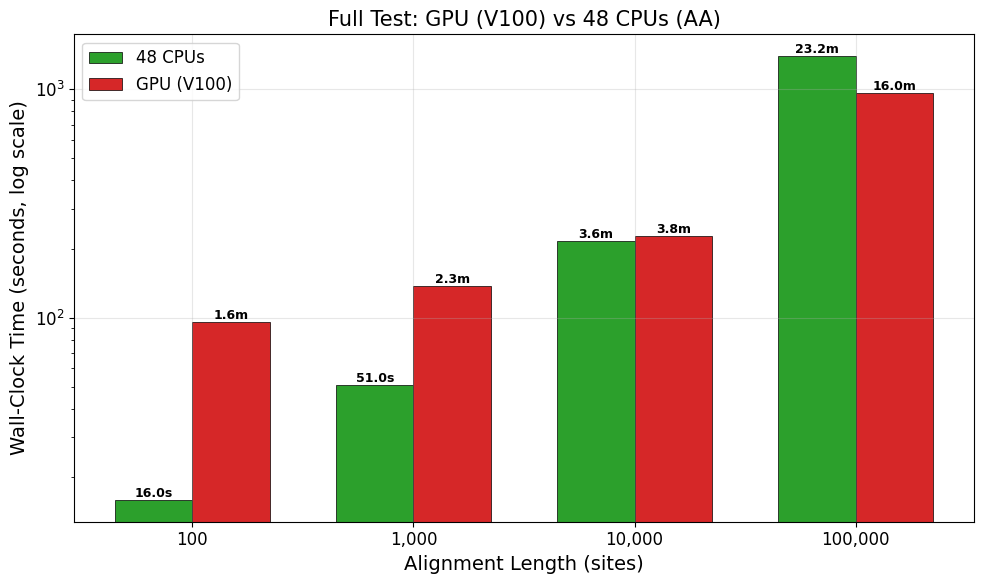

In [35]:
# GPU vs 48 CPUs bar chart (AA)
if 'GPU (V100)' in time_pivot_aa.columns and '48 CPUs' in time_pivot_aa.columns:
    common_idx_aa = time_pivot_aa[['GPU (V100)', '48 CPUs']].dropna().index
    
    fig, ax = plt.subplots(figsize=(10, 6))
    x_labels = [f'{l:,}' for l in common_idx_aa]
    gpu_times = [time_pivot_aa.loc[l, 'GPU (V100)'] for l in common_idx_aa]
    cpu48_times = [time_pivot_aa.loc[l, '48 CPUs'] for l in common_idx_aa]
    
    x = np.arange(len(x_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, cpu48_times, width, label='48 CPUs', color=colors['48 CPUs'], edgecolor='black', linewidth=0.5)
    bars2 = ax.bar(x + width/2, gpu_times, width, label='GPU (V100)', color=colors['GPU (V100)'], edgecolor='black', linewidth=0.5)
    
    for bar, v in zip(bars1, cpu48_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bar, v in zip(bars2, gpu_times):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                fmt_time(v), ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_yscale('log')
    ax.set_xlabel('Alignment Length (sites)', fontsize=14)
    ax.set_ylabel('Wall-Clock Time (seconds, log scale)', fontsize=14)
    ax.set_title('Full Test: GPU (V100) vs 48 CPUs (AA)', fontsize=15)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, 'gpu_vs_48cpu_bars_AA.png'), dpi=150, bbox_inches='tight')
    plt.show()

---
# Part 3: Combined DNA + AA Comparison

## 15. Side-by-Side Wall-Clock Time (DNA vs AA)

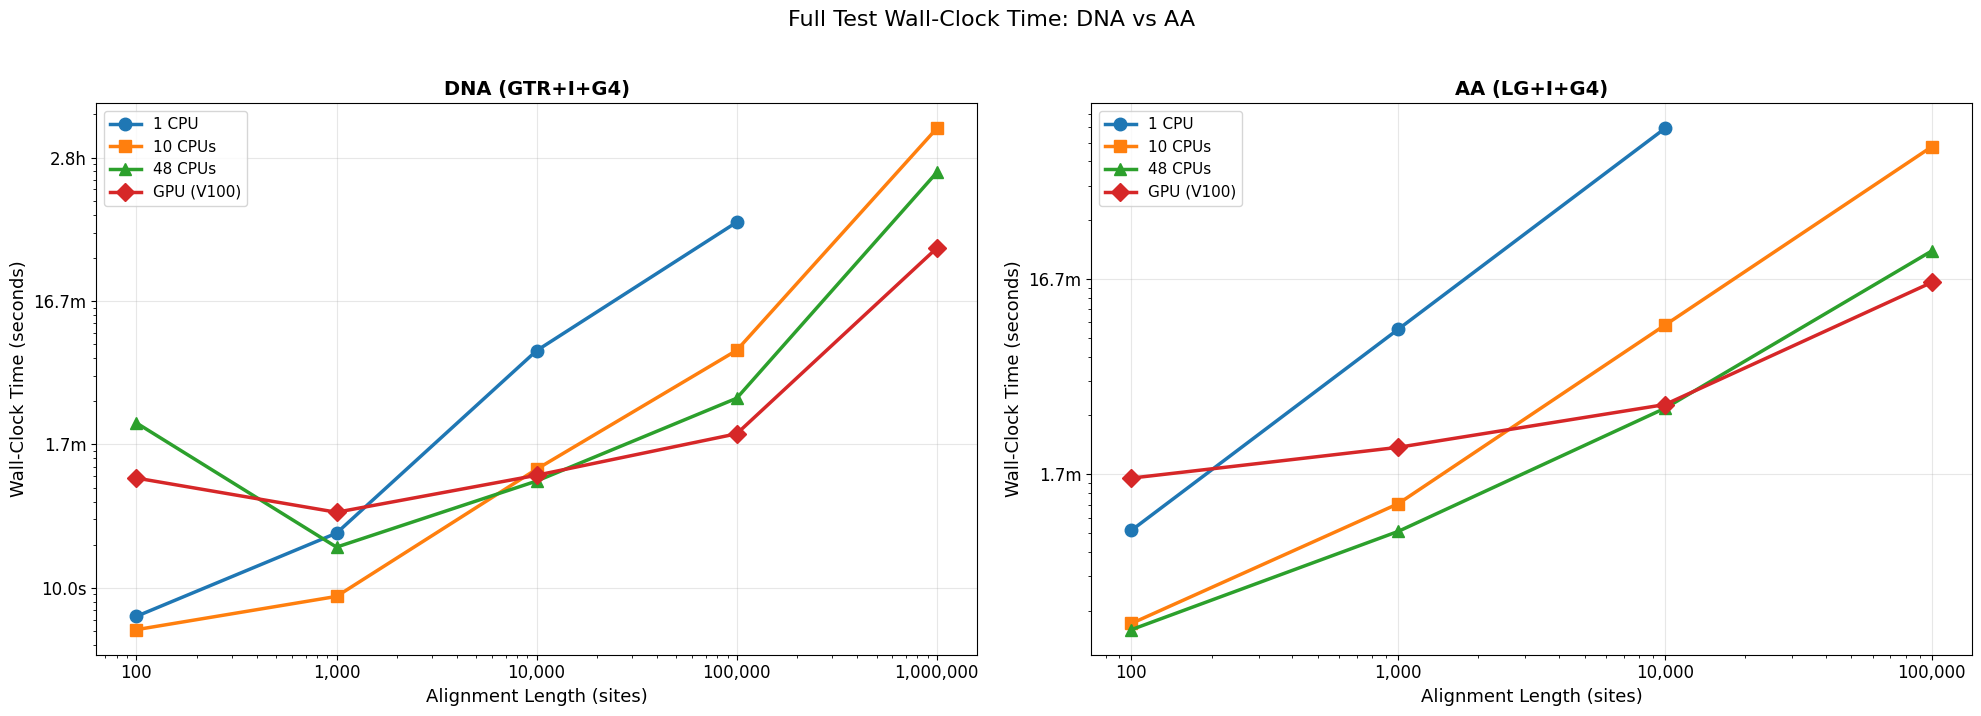

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# DNA
for wf in [c for c in wf_order if c in time_pivot_dna.columns]:
    data = time_pivot_dna[wf].dropna()
    ax1.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Alignment Length (sites)', fontsize=13)
ax1.set_ylabel('Wall-Clock Time (seconds)', fontsize=13)
ax1.set_title('DNA (GTR+I+G4)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: fmt_time(x)))

# AA
for wf in [c for c in wf_order if c in time_pivot_aa.columns]:
    data = time_pivot_aa[wf].dropna()
    ax2.plot(data.index, data.values, marker=markers[wf], label=wf,
            color=colors[wf], linewidth=2.5, markersize=9)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Alignment Length (sites)', fontsize=13)
ax2.set_ylabel('Wall-Clock Time (seconds)', fontsize=13)
ax2.set_title('AA (LG+I+G4)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: fmt_time(x)))

fig.suptitle('Full Test Wall-Clock Time: DNA vs AA', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'wall_time_dna_vs_aa.png'), dpi=150, bbox_inches='tight')
plt.show()

## 16. Side-by-Side Speedup (DNA vs AA)

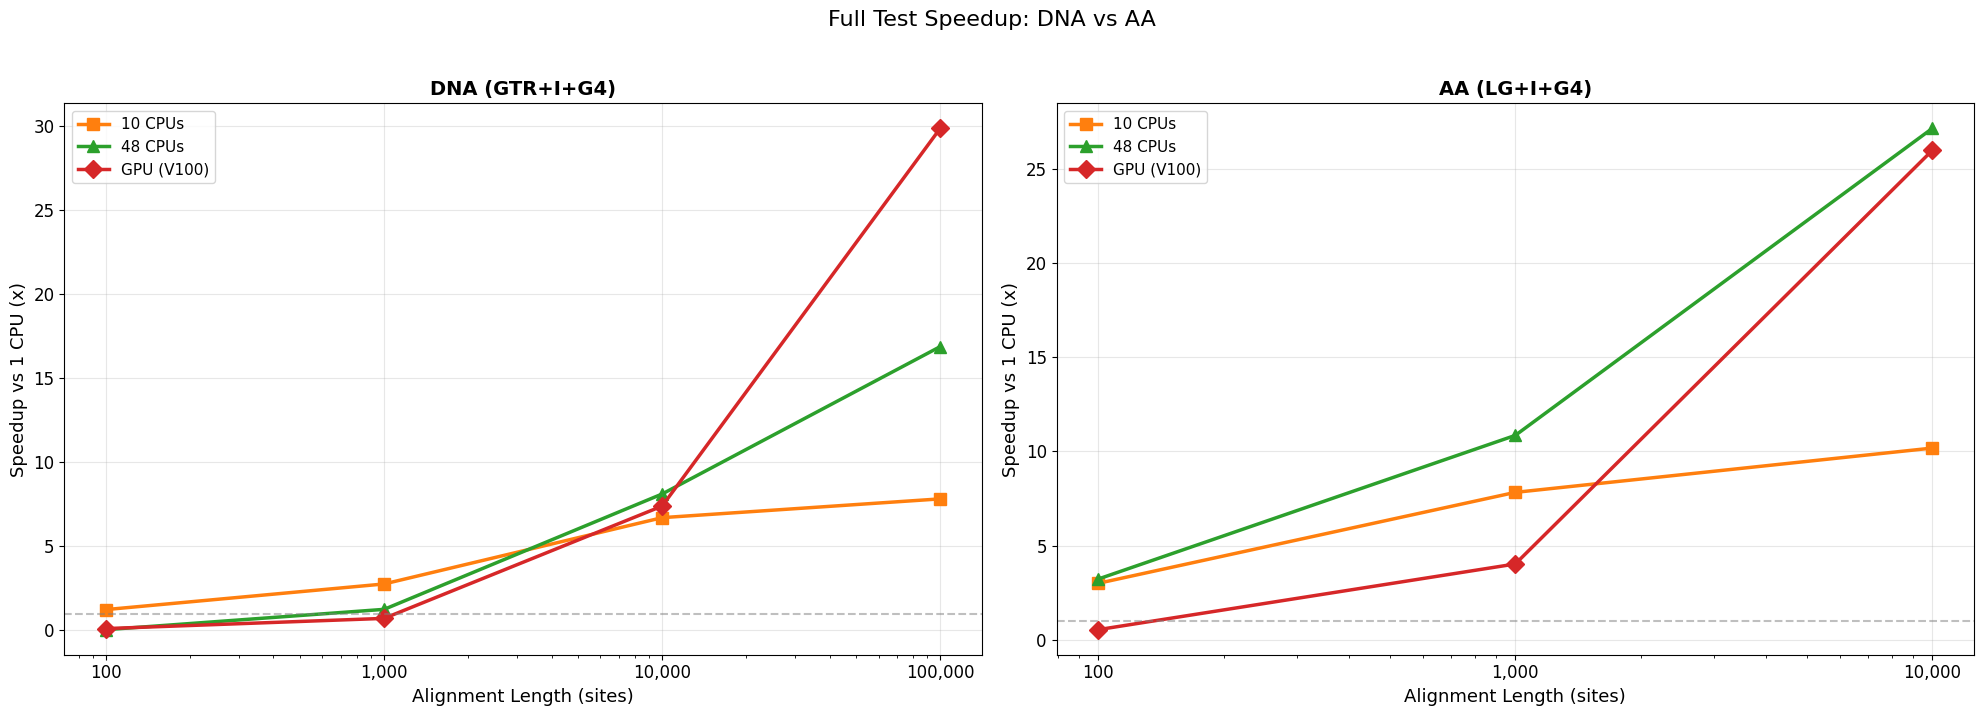

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# DNA speedup
if '1 CPU' in time_pivot_dna.columns:
    for wf in [c for c in wf_order if c in time_pivot_dna.columns and c != '1 CPU']:
        data = speedup_df_dna[wf].dropna()
        ax1.plot(data.index, data.values, marker=markers[wf], label=f'{wf}',
                color=colors[wf], linewidth=2.5, markersize=9)
    ax1.set_xscale('log')
    ax1.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Alignment Length (sites)', fontsize=13)
    ax1.set_ylabel('Speedup vs 1 CPU (x)', fontsize=13)
    ax1.set_title('DNA (GTR+I+G4)', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11)
    ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# AA speedup
if '1 CPU' in time_pivot_aa.columns:
    for wf in [c for c in wf_order if c in time_pivot_aa.columns and c != '1 CPU']:
        data = speedup_df_aa[wf].dropna()
        ax2.plot(data.index, data.values, marker=markers[wf], label=f'{wf}',
                color=colors[wf], linewidth=2.5, markersize=9)
    ax2.set_xscale('log')
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Alignment Length (sites)', fontsize=13)
    ax2.set_ylabel('Speedup vs 1 CPU (x)', fontsize=13)
    ax2.set_title('AA (LG+I+G4)', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)
    ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Full Test Speedup: DNA vs AA', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'speedup_dna_vs_aa.png'), dpi=150, bbox_inches='tight')
plt.show()

## 17. Combined Summary Table

In [38]:
# Combined summary: all data types, all lengths
df_all = pd.concat([df_dna, df_aa], ignore_index=True)

print('=' * 130)
print('COMBINED SUMMARY: All Workflows, All Data Types')
print('=' * 130)

for dtype in ['DNA', 'AA']:
    sub = df_all[df_all['data_type'] == dtype]
    if len(sub) == 0:
        continue
    
    model_name = 'GTR+I+G4' if dtype == 'DNA' else 'LG+I+G4'
    print(f'\n--- {dtype} ({model_name}) ---')
    
    time_piv = sub.pivot_table(index='length', columns='workflow_label', values='wall_time_sec', aggfunc='first')
    time_piv = time_piv[[c for c in wf_order if c in time_piv.columns]]
    
    lnl_piv = sub.pivot_table(index='length', columns='workflow_label', values='log_likelihood', aggfunc='first')
    lnl_piv = lnl_piv[[c for c in wf_order if c in lnl_piv.columns]]
    
    for length in sorted(time_piv.index):
        row_parts = [f'  {length:>10,} sites:']
        for wf in wf_order:
            if wf in time_piv.columns:
                t = time_piv.loc[length, wf]
                if not pd.isna(t):
                    row_parts.append(f'{wf}={fmt_time(t):>8s}')
        
        # GPU vs 48 CPU speedup
        if 'GPU (V100)' in time_piv.columns and '48 CPUs' in time_piv.columns:
            gpu_t = time_piv.loc[length, 'GPU (V100)']
            cpu48_t = time_piv.loc[length, '48 CPUs']
            if not pd.isna(gpu_t) and not pd.isna(cpu48_t):
                ratio = cpu48_t / gpu_t
                row_parts.append(f'| GPU/48CPU={ratio:.2f}x')
        
        # lnL match
        if 'GPU (V100)' in lnl_piv.columns and '1 CPU' in lnl_piv.columns:
            gpu_lnl = lnl_piv.loc[length, 'GPU (V100)'] if length in lnl_piv.index else None
            cpu_lnl = lnl_piv.loc[length, '1 CPU'] if length in lnl_piv.index else None
            if gpu_lnl is not None and cpu_lnl is not None and not pd.isna(gpu_lnl) and not pd.isna(cpu_lnl):
                row_parts.append(f'| delta_lnL={abs(gpu_lnl - cpu_lnl):.4f}')
        
        print('  '.join(row_parts))

COMBINED SUMMARY: All Workflows, All Data Types

--- DNA (GTR+I+G4) ---
         100 sites:  1 CPU=    6.3s  10 CPUs=    5.1s  48 CPUs=    2.4m  GPU (V100)=   58.3s  | GPU/48CPU=2.42x  | delta_lnL=0.0000
       1,000 sites:  1 CPU=   24.1s  10 CPUs=    8.7s  48 CPUs=   19.3s  GPU (V100)=   33.7s  | GPU/48CPU=0.57x  | delta_lnL=0.0000
      10,000 sites:  1 CPU=    7.5m  10 CPUs=    1.1m  48 CPUs=   55.6s  GPU (V100)=    1.0m  | GPU/48CPU=0.91x  | delta_lnL=0.0005
     100,000 sites:  1 CPU=   59.1m  10 CPUs=    7.6m  48 CPUs=    3.5m  GPU (V100)=    2.0m  | GPU/48CPU=1.77x  | delta_lnL=0.0000
   1,000,000 sites:  10 CPUs=    4.4h  48 CPUs=    2.2h  GPU (V100)=   39.0m  | GPU/48CPU=3.37x

--- AA (LG+I+G4) ---
         100 sites:  1 CPU=   51.6s  10 CPUs=   17.2s  48 CPUs=   16.0s  GPU (V100)=    1.6m  | GPU/48CPU=0.17x  | delta_lnL=0.0000
       1,000 sites:  1 CPU=    9.2m  10 CPUs=    1.2m  48 CPUs=   51.0s  GPU (V100)=    2.3m  | GPU/48CPU=0.37x  | delta_lnL=0.0000
      10,000 sites

## 18. Data Completeness Report

In [39]:
# Show which runs are complete vs missing
print('Data Completeness (from .iqtree files):')
print()

for dtype in ['DNA', 'AA']:
    print(f'=== {dtype} ===')
    sub = df_all[df_all['data_type'] == dtype]
    for length in [100, 1000, 10000, 100000, 1000000, 10000000]:
        len_sub = sub[sub['length'] == length]
        present = set(len_sub['workflow'].tolist())
        all_wfs = {'VANILA', 'OMP_10', 'OMP_48', 'OPENACC'}
        missing = all_wfs - present
        status = 'COMPLETE' if not missing else f'MISSING: {sorted(missing)}'
        has_iqtree = 'yes' if len(len_sub[len_sub.get('best_model', pd.Series()).notna()]) > 0 or 'best_model' in len_sub.columns else ''
        print(f'  len_{length:>10,}: {len(present)}/4 workflows  {status}')
    print()

Data Completeness (from .iqtree files):

=== DNA ===
  len_       100: 4/4 workflows  COMPLETE
  len_     1,000: 4/4 workflows  COMPLETE
  len_    10,000: 4/4 workflows  COMPLETE
  len_   100,000: 4/4 workflows  COMPLETE
  len_ 1,000,000: 3/4 workflows  MISSING: ['VANILA']
  len_10,000,000: 0/4 workflows  MISSING: ['OMP_10', 'OMP_48', 'OPENACC', 'VANILA']

=== AA ===
  len_       100: 4/4 workflows  COMPLETE
  len_     1,000: 4/4 workflows  COMPLETE
  len_    10,000: 4/4 workflows  COMPLETE
  len_   100,000: 3/4 workflows  MISSING: ['VANILA']
  len_ 1,000,000: 0/4 workflows  MISSING: ['OMP_10', 'OMP_48', 'OPENACC', 'VANILA']
  len_10,000,000: 0/4 workflows  MISSING: ['OMP_10', 'OMP_48', 'OPENACC', 'VANILA']


## 19. Gamma Shape Alpha Comparison

In [40]:
if 'gamma_alpha' in df_all.columns:
    for dtype in ['DNA', 'AA']:
        sub = df_all[df_all['data_type'] == dtype]
        if 'gamma_alpha' not in sub.columns or sub['gamma_alpha'].isna().all():
            continue
        gamma_pivot = sub.pivot_table(index='length', columns='workflow_label', values='gamma_alpha', aggfunc='first')
        gamma_pivot = gamma_pivot[[c for c in wf_order if c in gamma_pivot.columns]]
        print(f'Gamma shape alpha ({dtype}):')
        print(gamma_pivot.to_string(float_format='%.6f'))
        
        # Max difference
        for length in gamma_pivot.index:
            vals = gamma_pivot.loc[length].dropna().values
            if len(vals) >= 2:
                diff = max(vals) - min(vals)
                print(f'  len={length:>10,}: max diff = {diff:.8f}')
        print()

Gamma shape alpha (DNA):
workflow_label    1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                               
100            0.817200 0.817200 0.817200    0.817200
1000           1.008000 1.008000 1.008000    1.008000
10000          0.984300 0.984400 0.984400    0.984400
100000         1.009000 1.009000 1.009000    1.009000
1000000             NaN 0.999600 0.999600    0.999600
  len=       100: max diff = 0.00000000
  len=     1,000: max diff = 0.00000000
  len=    10,000: max diff = 0.00010000
  len=   100,000: max diff = 0.00000000
  len= 1,000,000: max diff = 0.00000000

Gamma shape alpha (AA):
workflow_label    1 CPU  10 CPUs  48 CPUs  GPU (V100)
length                                               
100            0.972000 0.972000 0.972000    0.972000
1000           1.008900 1.008900 1.008900    1.008900
10000          1.004600 1.004600 1.004600    1.004600
100000              NaN 0.996500 0.996600    0.996600
  len=       100: max diff = 0.00000000
  len=  